# Predicción

## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
import requests, io
import optuna
from shapely.geometry import Point
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.interpolate import interp1d
from statsmodels.tsa.statespace.sarimax import SARIMAX




Importing plotly failed. Interactive plots will not work.


## Datos

In [2]:
df_si = pd.read_csv('sell_in_suiza_geo.csv')
df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')
df_clima = pd.read_csv('clima_zurich_mensual.csv')
df_cm = pd.read_csv('limpio/customer_master_suiza.csv')
df_cp = pd.read_csv('limpio/CARPARK_suiza.csv')

## Formato

In [3]:
df_si['MONTH_DT'] = pd.to_datetime(df_si['MONTH_DT'])
df_so['MONTHDATE'] = pd.to_datetime(df_so['MONTHDATE'])
df_clima['fecha'] = pd.to_datetime(df_clima['fecha'])
df_si['CUSTOMERLATITUDE'] = df_si['CUSTOMERLATITUDE'].astype(str).str.replace(',', '.').astype(float)
df_si['CUSTOMERLONGITUDE'] = df_si['CUSTOMERLONGITUDE'].astype(str).str.replace(',', '.').astype(float)
df_cm['CUSTOMERLATITUDE'] = df_cm['CUSTOMERLATITUDE'].astype(str).str.replace(',', '.').astype(float)
df_cm['CUSTOMERLONGITUDE'] = df_cm['CUSTOMERLONGITUDE'].astype(str).str.replace(',', '.').astype(float)

print('Sell In:', df_si.shape)
print('Sell Out:', df_so.shape)
print('Clima:', df_clima.shape)

Sell In: (294132, 51)
Sell Out: (704699, 33)
Clima: (98, 4)


In [4]:
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_CHE_1.json"
response = requests.get(url)
cantons = gpd.read_file(io.BytesIO(response.content))

cp_coords = df_cm.groupby('CUSTOMERPOSTALCODE').agg(
    lat=('CUSTOMERLATITUDE', 'mean'),
    lon=('CUSTOMERLONGITUDE', 'mean')
).reset_index()

# Spatial join CP -> cantón
cp_coords_geo = cp_coords.dropna(subset=['lat', 'lon']).copy()
cp_coords_geo['geometry'] = cp_coords_geo.apply(
    lambda row: Point(row['lon'], row['lat']), axis=1)
cp_gdf = gpd.GeoDataFrame(cp_coords_geo, geometry='geometry', crs='EPSG:4326')
cantons = cantons.to_crs('EPSG:4326')

cp_canton = gpd.sjoin(cp_gdf, cantons[['NAME_1', 'geometry']],
                       how='left', predicate='within')
cp_canton = cp_canton[['CUSTOMERPOSTALCODE', 'NAME_1']].rename(
    columns={'NAME_1': 'CANTON'})

# Añadir cantón a Sell In y Sell Out
df_si['CUSTOMERPOSTALCODE'] = df_si['CUSTOMERPOSTALCODE'].dropna().astype(int)
df_so['POSTALCODE'] = df_so['POSTALCODE'].dropna().astype(int)

df_si = df_si.merge(cp_canton, on='CUSTOMERPOSTALCODE', how='left')
df_so = df_so.merge(cp_canton, left_on='POSTALCODE',
                    right_on='CUSTOMERPOSTALCODE', how='left')

print('CANTON en Sell In:', df_si['CANTON'].notnull().sum())
print('CANTON en Sell Out:', df_so['CANTON'].notnull().sum())

CANTON en Sell In: 288527
CANTON en Sell Out: 567207


## Series temporales

##### Sell In y Sell out por cantón y mes

In [5]:
so_canton_mes = df_so.groupby(['CANTON', 'MONTHDATE'])['TOTALSELLOUTQTTY'].sum().reset_index()
so_canton_mes.columns = ['canton', 'fecha', 'sell_out']

si_canton_mes = df_si.groupby(['CANTON', 'MONTH_DT'])['BILLED_QTY'].sum().reset_index()
si_canton_mes.columns = ['canton', 'fecha', 'sell_in']

# Verificar
print('Sell Out por cantón-mes:', so_canton_mes.shape)
print('Sell In por cantón-mes:', si_canton_mes.shape)
print('\nCantones únicos SO:', so_canton_mes['canton'].nunique())
print('Cantones únicos SI:', si_canton_mes['canton'].nunique())
print('\nRango temporal SO:', so_canton_mes['fecha'].min(), '→', so_canton_mes['fecha'].max())
print('Rango temporal SI:', si_canton_mes['fecha'].min(), '→', si_canton_mes['fecha'].max())

Sell Out por cantón-mes: (2436, 3)
Sell In por cantón-mes: (1011, 3)

Cantones únicos SO: 26
Cantones únicos SI: 26

Rango temporal SO: 2018-01-01 00:00:00 → 2026-02-01 00:00:00
Rango temporal SI: 2023-01-01 00:00:00 → 2026-03-01 00:00:00


In [6]:
# Merge Sell Out + Sell In + Clima
df_master = so_canton_mes.merge(
    si_canton_mes, on=['canton', 'fecha'], how='left'
).merge(
    df_clima, on='fecha', how='left'
)

# Ordenar
df_master = df_master.sort_values(['canton', 'fecha']).reset_index(drop=True)

print('Shape master:', df_master.shape)
print('\nNulos por columna:')
print(df_master.isnull().sum())
print('\nPrimeras filas:')
print(df_master.head())

Shape master: (2436, 7)

Nulos por columna:
canton              0
fecha               0
sell_out            0
sell_in          1453
temp_media          0
precipitacion       0
nieve               0
dtype: int64

Primeras filas:
   canton      fecha  sell_out  sell_in  temp_media  precipitacion  nieve
0  Aargau 2018-01-01      16.0      NaN    4.209677          154.1  12.81
1  Aargau 2018-02-01      38.0      NaN   -1.107143           69.5  16.45
2  Aargau 2018-03-01      27.0      NaN    3.606452           75.7   8.19
3  Aargau 2018-04-01      38.0      NaN   12.123333           36.3   0.77
4  Aargau 2018-05-01      51.0      NaN   15.096774           83.1   0.00


### Feature Engineering

In [7]:
# Feature Engineering
df_master = df_master.sort_values(['canton', 'fecha']).reset_index(drop=True)

# Variables temporales
df_master['mes'] = df_master['fecha'].dt.month
df_master['año'] = df_master['fecha'].dt.year
df_master['trimestre'] = df_master['fecha'].dt.quarter

# Lag features de Sell Out (1, 2, 3, 6, 12 meses)
for lag in [1, 2, 3, 6, 12]:
    df_master[f'sell_out_lag{lag}'] = df_master.groupby('canton')['sell_out'].shift(lag)

# Rolling windows (media móvil 3 y 6 meses)
df_master['sell_out_roll3'] = df_master.groupby('canton')['sell_out'].transform(
    lambda x: x.shift(1).rolling(3).mean())
df_master['sell_out_roll6'] = df_master.groupby('canton')['sell_out'].transform(
    lambda x: x.shift(1).rolling(6).mean())

# Temperatura con lag 2 meses
df_master['temp_lag2'] = df_master.groupby('canton')['temp_media'].shift(2)
df_master['nieve_lag2'] = df_master.groupby('canton')['nieve'].shift(2)

# Variables cíclicas para el mes (seno y coseno)
df_master['mes_sin'] = np.sin(2 * np.pi * df_master['mes'] / 12)
df_master['mes_cos'] = np.cos(2 * np.pi * df_master['mes'] / 12)

print('Shape con features:', df_master.shape)
print('\nColumnas:', df_master.columns.tolist())
print('\nNulos por columna:')
print(df_master.isnull().sum())

Shape con features: (2436, 21)

Columnas: ['canton', 'fecha', 'sell_out', 'sell_in', 'temp_media', 'precipitacion', 'nieve', 'mes', 'año', 'trimestre', 'sell_out_lag1', 'sell_out_lag2', 'sell_out_lag3', 'sell_out_lag6', 'sell_out_lag12', 'sell_out_roll3', 'sell_out_roll6', 'temp_lag2', 'nieve_lag2', 'mes_sin', 'mes_cos']

Nulos por columna:
canton               0
fecha                0
sell_out             0
sell_in           1453
temp_media           0
precipitacion        0
nieve                0
mes                  0
año                  0
trimestre            0
sell_out_lag1       26
sell_out_lag2       52
sell_out_lag3       78
sell_out_lag6      156
sell_out_lag12     312
sell_out_roll3      78
sell_out_roll6     156
temp_lag2           52
nieve_lag2          52
mes_sin              0
mes_cos              0
dtype: int64


In [8]:
# Definir periodos de train y test
# Train: hasta dic 2024
# Test: ene 2025 - feb 2026 (14 meses)

fecha_corte = '2024-12-01'

df_train = df_master[df_master['fecha'] <= fecha_corte].copy()
df_test = df_master[df_master['fecha'] > fecha_corte].copy()

print('Train:', df_train.shape)
print('Test:', df_test.shape)
print('\nTrain - rango:', df_train['fecha'].min(), '→', df_train['fecha'].max())
print('Test - rango:', df_test['fecha'].min(), '→', df_test['fecha'].max())

# Features que usaremos
features = ['mes', 'año', 'trimestre', 'mes_sin', 'mes_cos',
            'sell_out_lag1', 'sell_out_lag2', 'sell_out_lag3',
            'sell_out_lag6', 'sell_out_lag12',
            'sell_out_roll3', 'sell_out_roll6',
            'temp_lag2', 'nieve_lag2', 'precipitacion']

target = 'sell_out'

print('\nFeatures:', len(features))

Train: (2073, 21)
Test: (363, 21)

Train - rango: 2018-01-01 00:00:00 → 2024-12-01 00:00:00
Test - rango: 2025-01-01 00:00:00 → 2026-02-01 00:00:00

Features: 15


### Modelos baseline

In [9]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Baseline 1 - Naive: predice el valor del mes anterior
df_test = df_test.copy()
df_test['pred_naive'] = df_test['sell_out_lag1']

# Baseline 2 - Media histórica por cantón y mes
media_canton_mes = df_train.groupby(['canton', 'mes'])['sell_out'].mean().reset_index()
media_canton_mes.columns = ['canton', 'mes', 'pred_media']
df_test = df_test.merge(media_canton_mes, on=['canton', 'mes'], how='left')

# Evaluar baselines
mask = df_test['pred_naive'].notnull() & df_test['pred_media'].notnull()
y_true = df_test.loc[mask, 'sell_out']

for nombre, col in [('Naive', 'pred_naive'), ('Media histórica', 'pred_media')]:
    y_pred = df_test.loc[mask, col]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true.values, y_pred.values)
    print(f'{nombre}:  MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_val:.1f}%')

Naive:  MAE=448.0 | RMSE=836.3 | MAPE=66.4%
Media histórica:  MAE=504.0 | RMSE=956.3 | MAPE=50.9%


### Modelo XGBoost

In [10]:
# Preparar datos eliminando nulos en features
df_train_xgb = df_train[features + [target]].dropna()
df_test_xgb = df_test[features + [target, 'canton', 'fecha']].dropna(subset=features)

X_train = df_train_xgb[features]
y_train = df_train_xgb[target]
X_test = df_test_xgb[features]
y_test = df_test_xgb[target]

# Entrenar XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

# Predecir
y_pred_xgb = xgb.predict(X_test)

# Evaluar
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_val = mape(y_test.values, y_pred_xgb)

print(f'XGBoost:  MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_val:.1f}%')

XGBoost:  MAE=259.3 | RMSE=486.4 | MAPE=92.5%


In [11]:
# Análisis de errores por cantón
df_test_xgb = df_test_xgb.copy()
df_test_xgb['pred_xgb'] = y_pred_xgb
df_test_xgb['error_abs'] = np.abs(df_test_xgb['sell_out'] - df_test_xgb['pred_xgb'])
df_test_xgb['error_pct'] = np.abs(df_test_xgb['sell_out'] - df_test_xgb['pred_xgb']) / \
                            df_test_xgb['sell_out'].replace(0, np.nan) * 100

error_canton = df_test_xgb.groupby('canton').agg(
    volumen_medio=('sell_out', 'mean'),
    mae=('error_abs', 'mean'),
    mape=('error_pct', 'mean')
).sort_values('mape', ascending=False)

print(error_canton.round(1))

                       volumen_medio     mae   mape
canton                                             
AppenzellAusserrhoden           58.1    56.3  750.1
AppenzellInnerrhoden             2.9    21.8  292.4
Obwalden                        85.9    65.2  215.9
Jura                           178.8   109.5  150.6
Uri                             44.8    26.9  127.1
Glarus                          73.6    60.1  109.5
Schaffhausen                    51.8    35.4  105.1
Zug                            688.1   629.5  101.5
Nidwalden                      176.9    82.0   76.8
Neuchâtel                      364.1   138.0   62.5
Basel-Stadt                    341.4   134.2   53.7
Genève                         475.4   162.5   45.7
Valais                         901.3   253.3   42.2
Schwyz                         509.6   166.4   40.7
Graubünden                     708.1   160.8   40.1
Thurgau                        519.7   164.8   39.3
Basel-Landschaft               518.9   169.3   30.8
Lucerne     

El modelo funciona bien para cantones con gran volumen y mal para cantones con poco volumen, solución, estratificar, modelos para grandes y modelos para pequeños

### Estratificación

In [12]:
# Volumen medio por cantón solo en periodo reciente (2023-2026)
volumen_reciente = df_train[df_train['fecha'] >= '2023-01-01'].groupby('canton')['sell_out'].mean()

print('Volumen medio 2023-2026 por cantón:')
print(volumen_reciente.sort_values(ascending=False).round(0))

# Redefinir grupos con periodo reciente
cantones_grandes = volumen_reciente[volumen_reciente >= 500].index.tolist()
cantones_pequeños = volumen_reciente[volumen_reciente < 500].index.tolist()

print(f'\nCantones grandes (≥500 u/mes): {len(cantones_grandes)}')
print(cantones_grandes)
print(f'\nCantones pequeños (<500 u/mes): {len(cantones_pequeños)}')
print(cantones_pequeños)

Volumen medio 2023-2026 por cantón:
canton
Solothurn                5226.0
Zürich                   3821.0
Vaud                     2234.0
Bern                     2071.0
Ticino                   1859.0
Aargau                   1619.0
Zug                      1310.0
Fribourg                 1000.0
Valais                    902.0
Graubünden                767.0
SanktGallen               764.0
Lucerne                   706.0
Genève                    518.0
Schwyz                    498.0
Thurgau                   471.0
Neuchâtel                 468.0
Basel-Landschaft          428.0
Basel-Stadt               252.0
Jura                      243.0
Nidwalden                 160.0
Glarus                    104.0
Obwalden                   70.0
AppenzellAusserrhoden      58.0
Schaffhausen               57.0
Uri                        48.0
AppenzellInnerrhoden        3.0
Name: sell_out, dtype: float64

Cantones grandes (≥500 u/mes): 13
['Aargau', 'Bern', 'Fribourg', 'Genève', 'Graubünden', 'Luc

### Cantones Grandes (con mayor volumen)

##### XGBoost

In [13]:
# Filtrar solo cantones grandes
df_train_grandes = df_train[df_train['canton'].isin(cantones_grandes)]
df_test_grandes = df_test[df_test['canton'].isin(cantones_grandes)]

# Preparar datos
df_train_xgb_g = df_train_grandes[features + [target]].dropna()
df_test_xgb_g = df_test_grandes[features + [target, 'canton', 'fecha']].dropna(subset=features)

X_train_g = df_train_xgb_g[features]
y_train_g = df_train_xgb_g[target]
X_test_g = df_test_xgb_g[features]
y_test_g = df_test_xgb_g[target]

# Entrenar XGBoost cantones grandes
xgb_grandes = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_grandes.fit(X_train_g, y_train_g)

# Evaluar
y_pred_g = xgb_grandes.predict(X_test_g)
mae = mean_absolute_error(y_test_g, y_pred_g)
rmse = np.sqrt(mean_squared_error(y_test_g, y_pred_g))
mape_val = mape(y_test_g.values, y_pred_g)

print(f'XGBoost cantones grandes:  MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_val:.1f}%')

# Detalle por cantón
df_test_xgb_g = df_test_xgb_g.copy()
df_test_xgb_g['pred_xgb'] = y_pred_g
df_test_xgb_g['error_pct'] = np.abs(df_test_xgb_g['sell_out'] - df_test_xgb_g['pred_xgb']) / \
                               df_test_xgb_g['sell_out'].replace(0, np.nan) * 100

print('\nMAPE por cantón:')
print(df_test_xgb_g.groupby('canton')['error_pct'].mean().sort_values().round(1))

XGBoost cantones grandes:  MAE=425.9 | RMSE=654.7 | MAPE=38.8%

MAPE por cantón:
canton
Ticino          19.3
Bern            19.5
Aargau          19.8
Fribourg        22.4
Zürich          23.9
Vaud            30.3
SanktGallen     31.0
Solothurn       33.4
Lucerne         38.9
Valais          43.6
Graubünden      47.3
Genève          71.6
Zug            103.7
Name: error_pct, dtype: float64


In [14]:
# Grid search con validación temporal
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8],
}

xgb_cv = XGBRegressor(random_state=42, colsample_bytree=0.8)

grid_search = GridSearchCV(
    xgb_cv, param_grid, 
    cv=tscv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_g, y_train_g)

print('Mejores parámetros:', grid_search.best_params_)
print('Mejor MAE CV:', -grid_search.best_score_.round(1))

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Mejores parámetros: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Mejor MAE CV: 426.3


In [15]:
# Reentrenar con mejores parámetros
xgb_opt = XGBRegressor(
    learning_rate=0.03,
    max_depth=3,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_opt.fit(X_train_g, y_train_g)

# Evaluar
y_pred_opt = xgb_opt.predict(X_test_g)
mae = mean_absolute_error(y_test_g, y_pred_opt)
rmse = np.sqrt(mean_squared_error(y_test_g, y_pred_opt))
mape_val = mape(y_test_g.values, y_pred_opt)

print(f'XGBoost optimizado:  MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_val:.1f}%')

# Comparativa
print('\n=== Comparativa de modelos (cantones grandes) ===')
print(f'Naive:              MAPE=66.4%')
print(f'Media histórica:    MAPE=50.9%')
print(f'XGBoost inicial:    MAPE=38.8%')
print(f'XGBoost optimizado: MAPE={mape_val:.1f}%')

XGBoost optimizado:  MAE=431.6 | RMSE=671.0 | MAPE=39.0%

=== Comparativa de modelos (cantones grandes) ===
Naive:              MAPE=66.4%
Media histórica:    MAPE=50.9%
XGBoost inicial:    MAPE=38.8%
XGBoost optimizado: MAPE=39.0%


##### Exponential Smoothing

In [16]:
resultados_ets = []

for canton in cantones_grandes + cantones_pequeños:
    df_c = df_master[df_master['canton'] == canton][['fecha', 'sell_out']].copy()
    df_c = df_c.set_index('fecha').sort_index().dropna()
    
    train_c = df_c[df_c.index <= '2024-12-01']
    test_c = df_c[df_c.index > '2024-12-01']
    
    if len(train_c) < 24 or len(test_c) == 0:
        continue
    
    try:
        model = ExponentialSmoothing(
            train_c['sell_out'],
            trend='add',
            seasonal='add',
            seasonal_periods=12
        )
        result = model.fit(optimized=True)
        pred = result.forecast(len(test_c))
        
        y_true = test_c['sell_out'].values
        mape_c = mape(y_true, pred.values)
        
        resultados_ets.append({
            'canton': canton,
            'mape_ets': mape_c,
            'grupo': 'grande' if canton in cantones_grandes else 'pequeño'
        })
    except Exception as e:
        print(f'Error en {canton}: {e}')

df_ets = pd.DataFrame(resultados_ets)
print('=== ETS por cantón ===')
print(df_ets.sort_values('mape_ets').round(1).to_string())
print(f'\nMAPE medio ETS grandes: {df_ets[df_ets["grupo"]=="grande"]["mape_ets"].mean():.1f}%')
print(f'MAPE medio ETS pequeños: {df_ets[df_ets["grupo"]=="pequeño"]["mape_ets"].mean():.1f}%')

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, s

=== ETS por cantón ===
                   canton  mape_ets    grupo
16            Basel-Stadt      17.0  pequeño
0                  Aargau      18.0   grande
20              Nidwalden      22.8  pequeño
12                 Zürich      24.3   grande
24                Thurgau      28.9  pequeño
15       Basel-Landschaft      33.0  pequeño
3                  Genève      33.8   grande
7               Solothurn      37.8   grande
5                 Lucerne      38.7   grande
1                    Bern      39.6   grande
23                 Schwyz      39.8  pequeño
2                Fribourg      39.9   grande
10                   Vaud      42.3   grande
4              Graubünden      46.9   grande
9                  Valais      49.1   grande
6             SanktGallen      50.2   grande
8                  Ticino      54.7   grande
17                 Glarus      73.0  pequeño
14   AppenzellInnerrhoden      77.3  pequeño
25                    Uri      78.5  pequeño
22           Schaffhausen      8

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


##### SARIMA

In [17]:
# Entrenar SARIMA por cantón
resultados_sarima = []

for canton in cantones_grandes:
    print(f'Entrenando {canton}...')
    
    # Serie temporal del cantón
    df_c = df_master[df_master['canton'] == canton][['fecha', 'sell_out']].copy()
    df_c = df_c.set_index('fecha').sort_index()
    df_c = df_c.dropna()
    
    train_c = df_c[df_c.index <= '2024-12-01']
    test_c = df_c[df_c.index > '2024-12-01']
    
    try:
        # SARIMA(1,1,1)(1,1,1,12) - orden estacional mensual
        model = SARIMAX(train_c['sell_out'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        
        result = model.fit(disp=False)
        
        # Predecir
        pred = result.forecast(steps=len(test_c))
        y_true = test_c['sell_out'].values
        
        mae_c = mean_absolute_error(y_true, pred)
        mape_c = mape(y_true, pred)
        
        resultados_sarima.append({
            'canton': canton, 'mae': mae_c, 'mape': mape_c
        })
    except Exception as e:
        print(f'  Error en {canton}: {e}')

df_sarima = pd.DataFrame(resultados_sarima)
print('\n=== SARIMA por cantón ===')
print(df_sarima.sort_values('mape').round(1).to_string())
print(f'\nMAPE medio SARIMA: {df_sarima["mape"].mean():.1f}%')

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Entrenando Aargau...
Entrenando Bern...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Entrenando Fribourg...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

Entrenando Zug...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Entrenando Zürich...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



=== SARIMA por cantón ===
         canton     mae   mape
0        Aargau   214.8   13.9
12       Zürich   623.3   21.8
8        Ticino   301.9   23.2
3        Genève    94.1   23.4
1          Bern   381.0   27.1
10         Vaud   515.9   27.6
5       Lucerne   150.3   32.5
6   SanktGallen   192.7   36.8
7     Solothurn  1391.0   40.2
2      Fribourg   266.5   41.1
4    Graubünden   177.8   46.4
9        Valais   295.9   50.8
11          Zug   879.3  163.9

MAPE medio SARIMA: 42.2%


### Comparación entre modelos

##### Comparativa SARIMA vs XGBoost en cantones grandes


In [18]:
comparativa = df_sarima.merge(
    df_test_xgb_g.groupby('canton')['error_pct'].mean().reset_index().rename(
        columns={'error_pct': 'mape_xgb'}),
    on='canton'
).rename(columns={'mape': 'mape_sarima'})

comparativa['mejor'] = comparativa.apply(
    lambda x: 'SARIMA' if x['mape_sarima'] < x['mape_xgb'] else 'XGBoost', axis=1)

print(comparativa[['canton', 'mape_sarima', 'mape_xgb', 'mejor']].sort_values('mape_sarima').round(1).to_string())

         canton  mape_sarima  mape_xgb    mejor
0        Aargau         13.9      19.8   SARIMA
12       Zürich         21.8      23.9   SARIMA
8        Ticino         23.2      19.3  XGBoost
3        Genève         23.4      71.6   SARIMA
1          Bern         27.1      19.5  XGBoost
10         Vaud         27.6      30.3   SARIMA
5       Lucerne         32.5      38.9   SARIMA
6   SanktGallen         36.8      31.0  XGBoost
7     Solothurn         40.2      33.4  XGBoost
2      Fribourg         41.1      22.4  XGBoost
4    Graubünden         46.4      47.3   SARIMA
9        Valais         50.8      43.6  XGBoost
11          Zug        163.9     103.7  XGBoost


### Cantones pequeños (Con menor volumen)

##### Media histórica por mes + SARIMA

In [19]:
resultados_pequeños = []

for canton in cantones_pequeños:
    df_c = df_master[df_master['canton'] == canton][['fecha', 'mes', 'sell_out']].copy()
    
    train_c = df_c[df_c['fecha'] <= '2024-12-01']
    test_c = df_c[df_c['fecha'] > '2024-12-01'].copy()
    
    # Media histórica por mes
    media_mes = train_c.groupby('mes')['sell_out'].mean()
    test_c['pred_media'] = test_c['mes'].map(media_mes)
    
    # SARIMA también para comparar
    try:
        serie = train_c.set_index('fecha')['sell_out'].dropna()
        model = SARIMAX(serie,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        result = model.fit(disp=False)
        pred_sarima = result.forecast(steps=len(test_c))
        
        y_true = test_c['sell_out'].values
        
        mape_media = mape(y_true, test_c['pred_media'].values)
        mape_sarima = mape(y_true, pred_sarima.values)
        
        resultados_pequeños.append({
            'canton': canton,
            'mape_media': mape_media,
            'mape_sarima': mape_sarima,
            'mejor': 'SARIMA' if mape_sarima < mape_media else 'Media'
        })
    except:
        resultados_pequeños.append({
            'canton': canton,
            'mape_media': mape_media,
            'mape_sarima': None,
            'mejor': 'Media'
        })

df_pequeños = pd.DataFrame(resultados_pequeños)
print(df_pequeños.sort_values('mape_media').round(1).to_string())

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages

                   canton  mape_media  mape_sarima   mejor
5                    Jura        27.7        103.2   Media
4                  Glarus        27.8         90.6   Media
12                    Uri        32.5         97.3   Media
6               Neuchâtel        34.5         84.4   Media
9            Schaffhausen        44.3         87.6   Media
10                 Schwyz        56.0         45.6  SARIMA
8                Obwalden        57.4        164.9   Media
11                Thurgau        57.6         27.1  SARIMA
2        Basel-Landschaft        59.6         35.1  SARIMA
1    AppenzellInnerrhoden        62.3         76.9   Media
3             Basel-Stadt        64.5         23.3  SARIMA
7               Nidwalden        64.7         32.6  SARIMA
0   AppenzellAusserrhoden       116.3        363.0   Media


SARIMA para comparar

##### Linear Regression con Features

In [20]:
resultados_ridge = []

for canton in cantones_pequeños:
    df_c = df_master[df_master['canton'] == canton].copy()
    
    train_c = df_c[df_c['fecha'] <= '2024-12-01'].dropna(subset=['sell_out_lag12'])
    test_c = df_c[df_c['fecha'] > '2024-12-01'].dropna(subset=['sell_out_lag12'])
    
    if len(train_c) < 12 or len(test_c) == 0:
        continue
    
    features_ridge = ['mes_sin', 'mes_cos', 'año', 
                      'sell_out_lag12', 'sell_out_lag1',
                      'temp_lag2', 'nieve_lag2']
    
    X_train_r = train_c[features_ridge].dropna()
    y_train_r = train_c.loc[X_train_r.index, 'sell_out']
    X_test_r = test_c[features_ridge].dropna()
    y_test_r = test_c.loc[X_test_r.index, 'sell_out']
    
    if len(X_train_r) < 12 or len(X_test_r) == 0:
        continue
    
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_r, y_train_r)
    pred_ridge = ridge.predict(X_test_r)
    
    mape_r = mape(y_test_r.values, pred_ridge)
    
    resultados_ridge.append({
        'canton': canton,
        'mape_ridge': mape_r
    })

df_ridge = pd.DataFrame(resultados_ridge)

# Comparativa completa cantones pequeños
comparativa_pequeños = df_pequeños.merge(df_ridge, on='canton', how='left')
comparativa_pequeños['mejor_final'] = comparativa_pequeños.apply(
    lambda x: min([
        ('Media', x['mape_media']),
        ('SARIMA', x['mape_sarima'] if pd.notnull(x['mape_sarima']) else 999),
        ('Ridge', x['mape_ridge'] if pd.notnull(x['mape_ridge']) else 999)
    ], key=lambda t: t[1])[0], axis=1
)

print(comparativa_pequeños[['canton', 'mape_media', 'mape_sarima', 
                              'mape_ridge', 'mejor_final']].round(1).to_string())

                   canton  mape_media  mape_sarima  mape_ridge mejor_final
0   AppenzellAusserrhoden       116.3        363.0       436.8       Media
1    AppenzellInnerrhoden        62.3         76.9        49.3       Ridge
2        Basel-Landschaft        59.6         35.1        36.8      SARIMA
3             Basel-Stadt        64.5         23.3        29.6      SARIMA
4                  Glarus        27.8         90.6        63.3       Media
5                    Jura        27.7        103.2       145.4       Media
6               Neuchâtel        34.5         84.4        54.0       Media
7               Nidwalden        64.7         32.6        51.4      SARIMA
8                Obwalden        57.4        164.9       121.4       Media
9            Schaffhausen        44.3         87.6        94.8       Media
10                 Schwyz        56.0         45.6        46.5      SARIMA
11                Thurgau        57.6         27.1        32.8      SARIMA
12                    Uri

### Comparación general todos los modelos en cantones grandes y pequeños

In [21]:
# Comparativa completa todos los modelos - cantones grandes
comp_grandes = df_sarima.rename(columns={'mae': 'mae_sarima', 'mape': 'mape_sarima'}).merge(
    df_test_xgb_g.groupby('canton')['error_pct'].mean().reset_index().rename(
        columns={'error_pct': 'mape_xgb'}), on='canton'
).merge(
    df_ets[df_ets['grupo']=='grande'][['canton', 'mape_ets']], on='canton'
)

# Mejor modelo por cantón
comp_grandes['mejor'] = comp_grandes[['mape_sarima', 'mape_xgb', 'mape_ets']].idxmin(axis=1).str.replace('mape_', '')

print('=== Comparativa cantones grandes ===')
print(comp_grandes[['canton', 'mape_sarima', 'mape_xgb', 'mape_ets', 'mejor']].sort_values('mape_sarima').round(1).to_string())

# Comparativa cantones pequeños
comp_pequeños = df_pequeños.merge(
    df_ets[df_ets['grupo']=='pequeño'][['canton', 'mape_ets']], on='canton', how='left'
).merge(
    df_ridge, on='canton', how='left'
)

comp_pequeños['mejor'] = comp_pequeños[['mape_media', 'mape_sarima', 'mape_ets', 'mape_ridge']].idxmin(axis=1).str.replace('mape_', '')

print('\n=== Comparativa cantones pequeños ===')
print(comp_pequeños[['canton', 'mape_media', 'mape_sarima', 'mape_ets', 'mape_ridge', 'mejor']].sort_values('mape_media').round(1).to_string())

=== Comparativa cantones grandes ===
         canton  mape_sarima  mape_xgb  mape_ets   mejor
0        Aargau         13.9      19.8      18.0  sarima
12       Zürich         21.8      23.9      24.3  sarima
8        Ticino         23.2      19.3      54.7     xgb
3        Genève         23.4      71.6      33.8  sarima
1          Bern         27.1      19.5      39.6     xgb
10         Vaud         27.6      30.3      42.3  sarima
5       Lucerne         32.5      38.9      38.7  sarima
6   SanktGallen         36.8      31.0      50.2     xgb
7     Solothurn         40.2      33.4      37.8     xgb
2      Fribourg         41.1      22.4      39.9     xgb
4    Graubünden         46.4      47.3      46.9  sarima
9        Valais         50.8      43.6      49.1     xgb
11          Zug        163.9     103.7     177.8     xgb

=== Comparativa cantones pequeños ===
                   canton  mape_media  mape_sarima  mape_ets  mape_ridge   mejor
5                    Jura        27.7        

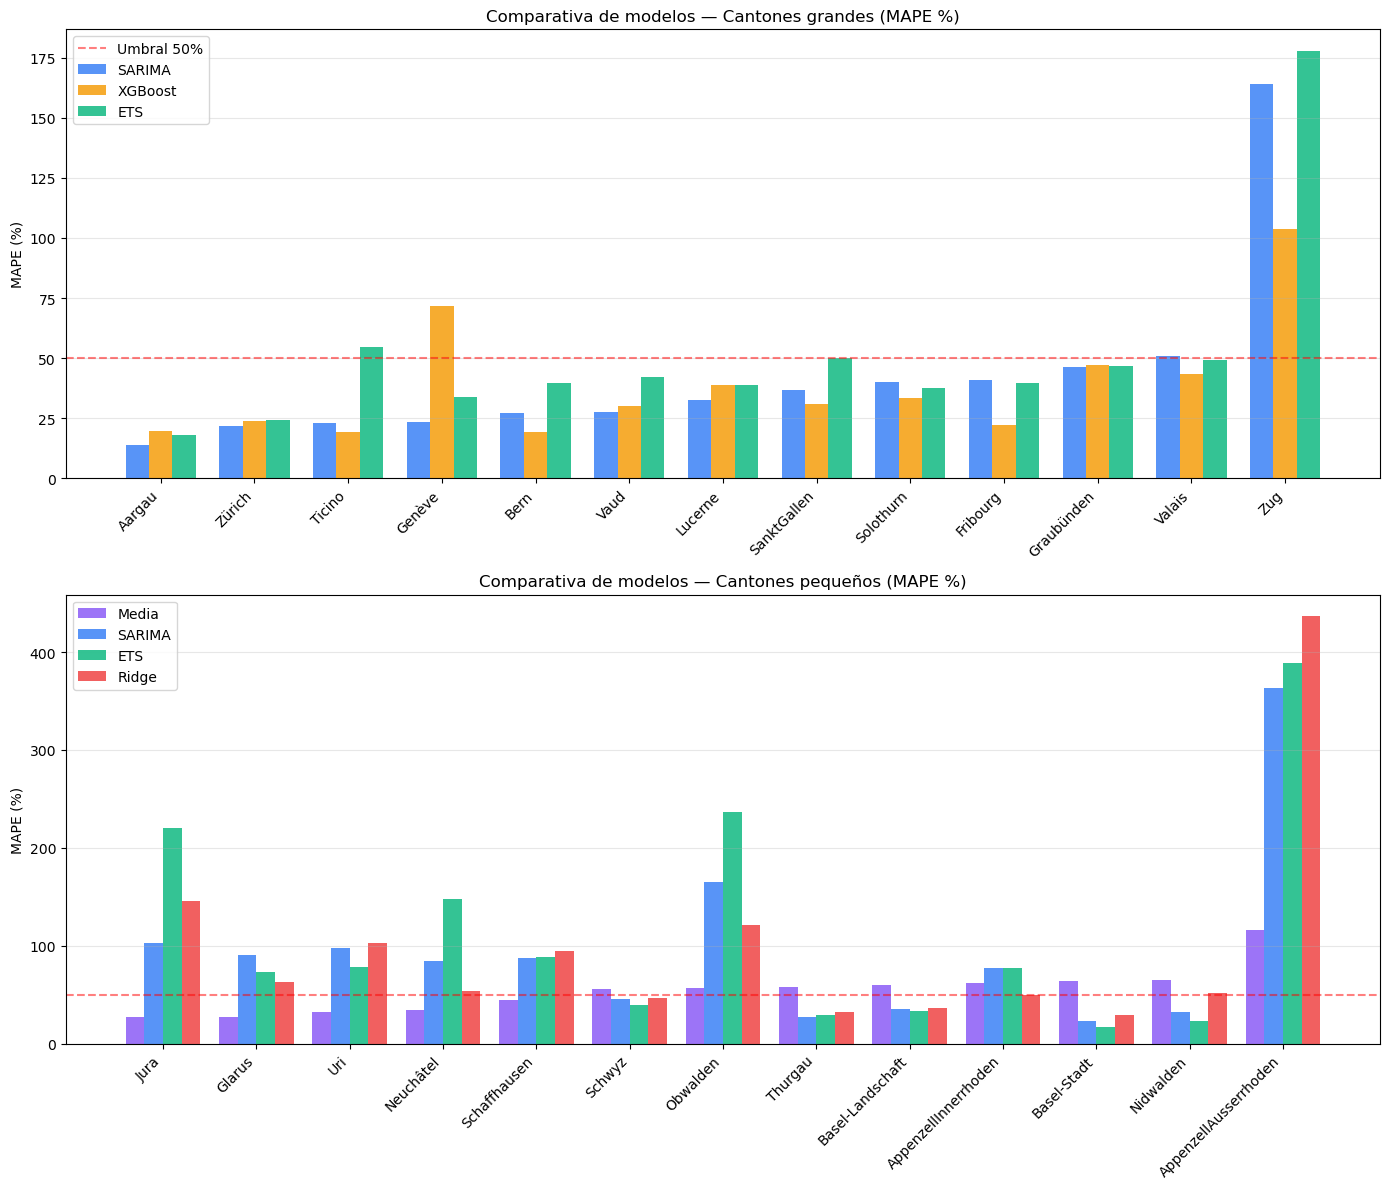

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Cantones grandes
comp_g = comp_grandes.set_index('canton')[['mape_sarima', 'mape_xgb', 'mape_ets']].sort_values('mape_sarima')
x = range(len(comp_g))
width = 0.25

axes[0].bar([i - width for i in x], comp_g['mape_sarima'], width=width, 
            color='#3B82F6', alpha=0.85, label='SARIMA')
axes[0].bar([i for i in x], comp_g['mape_xgb'], width=width, 
            color='#F59E0B', alpha=0.85, label='XGBoost')
axes[0].bar([i + width for i in x], comp_g['mape_ets'], width=width, 
            color='#10B981', alpha=0.85, label='ETS')
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Umbral 50%')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(comp_g.index, rotation=45, ha='right')
axes[0].set_title('Comparativa de modelos — Cantones grandes (MAPE %)')
axes[0].set_ylabel('MAPE (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Cantones pequeños
comp_p = comp_pequeños.set_index('canton')[['mape_media', 'mape_sarima', 
                                             'mape_ets', 'mape_ridge']].sort_values('mape_media')
x2 = range(len(comp_p))
width2 = 0.2

axes[1].bar([i - 1.5*width2 for i in x2], comp_p['mape_media'], width=width2,
            color='#8B5CF6', alpha=0.85, label='Media')
axes[1].bar([i - 0.5*width2 for i in x2], comp_p['mape_sarima'], width=width2,
            color='#3B82F6', alpha=0.85, label='SARIMA')
axes[1].bar([i + 0.5*width2 for i in x2], comp_p['mape_ets'], width=width2,
            color='#10B981', alpha=0.85, label='ETS')
axes[1].bar([i + 1.5*width2 for i in x2], comp_p['mape_ridge'], width=width2,
            color='#EF4444', alpha=0.85, label='Ridge')
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5)
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(comp_p.index, rotation=45, ha='right')
axes[1].set_title('Comparativa de modelos — Cantones pequeños (MAPE %)')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('modelado_comparativa_modelos_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Ensemble final
ensemble = []

# Cantones grandes
for _, row in comp_grandes.iterrows():
    mejor = row['mejor']
    mape_mejor = row[f'mape_{mejor}']
    ensemble.append({
        'canton': row['canton'],
        'grupo': 'grande',
        'modelo': mejor.upper(),
        'mape': mape_mejor
    })

# Cantones pequeños
for _, row in comp_pequeños.iterrows():
    mejor = row['mejor']
    mape_mejor = row[f'mape_{mejor}']
    ensemble.append({
        'canton': row['canton'],
        'grupo': 'pequeño',
        'modelo': mejor.upper(),
        'mape': mape_mejor
    })

df_ensemble = pd.DataFrame(ensemble).sort_values('mape')

print('=== ENSEMBLE FINAL ===')
print(df_ensemble.to_string(index=False))
print(f'\nMAPE medio ensemble: {df_ensemble["mape"].mean():.1f}%')
print(f'MAPE medio grandes: {df_ensemble[df_ensemble["grupo"]=="grande"]["mape"].mean():.1f}%')
print(f'MAPE medio pequeños: {df_ensemble[df_ensemble["grupo"]=="pequeño"]["mape"].mean():.1f}%')

=== ENSEMBLE FINAL ===
               canton   grupo modelo       mape
               Aargau  grande SARIMA  13.885022
          Basel-Stadt pequeño    ETS  16.977832
               Ticino  grande    XGB  19.314750
                 Bern  grande    XGB  19.477944
               Zürich  grande SARIMA  21.809741
             Fribourg  grande    XGB  22.410588
            Nidwalden pequeño    ETS  22.773315
               Genève  grande SARIMA  23.441674
              Thurgau pequeño SARIMA  27.050465
                 Vaud  grande SARIMA  27.561780
                 Jura pequeño  MEDIA  27.674753
               Glarus pequeño  MEDIA  27.805719
          SanktGallen  grande    XGB  30.956264
              Lucerne  grande SARIMA  32.457994
                  Uri pequeño  MEDIA  32.493467
     Basel-Landschaft pequeño    ETS  33.030731
            Solothurn  grande    XGB  33.414986
            Neuchâtel pequeño  MEDIA  34.502636
               Schwyz pequeño    ETS  39.847258
               Va

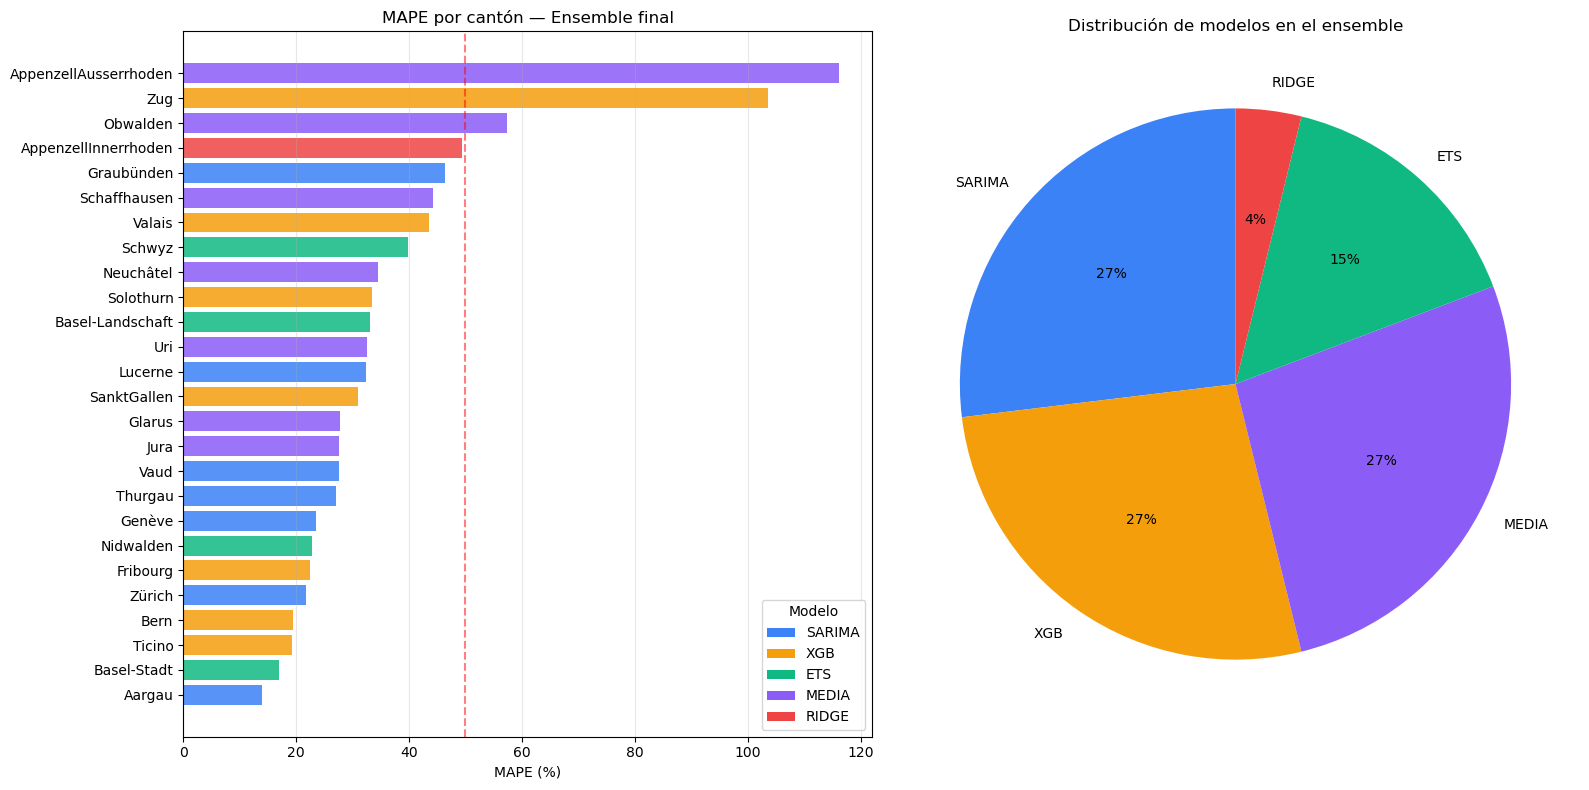


Distribución de modelos:
modelo
SARIMA    7
XGB       7
MEDIA     7
ETS       4
RIDGE     1
Name: count, dtype: int64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gráfico por cantón coloreado por modelo
colores_modelo = {
    'SARIMA': '#3B82F6', 
    'XGB': '#F59E0B', 
    'ETS': '#10B981', 
    'MEDIA': '#8B5CF6',
    'RIDGE': '#EF4444'
}

df_plot = df_ensemble.sort_values('mape')
colores = [colores_modelo[m] for m in df_plot['modelo']]

axes[0].barh(df_plot['canton'], df_plot['mape'], color=colores, alpha=0.85)
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Umbral 50%')
axes[0].set_title('MAPE por cantón — Ensemble final')
axes[0].set_xlabel('MAPE (%)')
axes[0].grid(True, alpha=0.3, axis='x')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) 
                   for m, c in colores_modelo.items()]
axes[0].legend(handles=legend_elements, title='Modelo')

# Distribución de modelos
modelo_count = df_ensemble['modelo'].value_counts()
axes[1].pie(modelo_count, labels=modelo_count.index, 
            colors=[colores_modelo[m] for m in modelo_count.index],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Distribución de modelos en el ensemble')

plt.tight_layout()
plt.savefig('modelado_ensemble_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDistribución de modelos:')
print(df_ensemble['modelo'].value_counts())

## Predicción para los próximos 12 meses (marzo 2026 - febrero 2027) por cantón según el modelo con mejor modelo.

In [25]:
# Fecha de última observación disponible
ultima_fecha = df_master['fecha'].max()
fechas_futuras = pd.date_range(start='2026-03-01', periods=12, freq='MS')

print(f'Última fecha disponible: {ultima_fecha}')
print(f'Predicciones: {fechas_futuras[0]} → {fechas_futuras[-1]}')

predicciones = []

for _, row in df_ensemble.iterrows():
    canton = row['canton']
    modelo = row['modelo']
    
    # Serie completa del cantón
    df_c = df_master[df_master['canton'] == canton][['fecha', 'sell_out']].copy()
    df_c = df_c.set_index('fecha').sort_index().dropna()
    
    try:
        if modelo == 'SARIMA':
            model = SARIMAX(df_c['sell_out'],
                           order=(1, 1, 1),
                           seasonal_order=(1, 1, 1, 12),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
            result = model.fit(disp=False)
            pred = result.forecast(steps=12)
            pred_values = pred.values
            
        elif modelo == 'XGB':
            # Reentrenar con todos los datos
            df_c_feat = df_master[df_master['canton'] == canton].copy()
            df_c_feat = df_c_feat.dropna(subset=features)
            xgb_final = XGBRegressor(learning_rate=0.03, max_depth=3,
                                      n_estimators=500, subsample=0.8,
                                      colsample_bytree=0.8, random_state=42)
            xgb_final.fit(df_c_feat[features], df_c_feat['sell_out'])
            
            # Generar features para fechas futuras
            df_fut = pd.DataFrame({'fecha': fechas_futuras})
            df_fut['mes'] = df_fut['fecha'].dt.month
            df_fut['año'] = df_fut['fecha'].dt.year
            df_fut['trimestre'] = df_fut['fecha'].dt.quarter
            df_fut['mes_sin'] = np.sin(2 * np.pi * df_fut['mes'] / 12)
            df_fut['mes_cos'] = np.cos(2 * np.pi * df_fut['mes'] / 12)
            
            # Lags del periodo más reciente
            ultimos = df_c['sell_out'].tail(12).values
            for i, lag in enumerate([1, 2, 3, 6, 12]):
                df_fut[f'sell_out_lag{lag}'] = ultimos[-lag] if lag <= len(ultimos) else ultimos[0]
            df_fut['sell_out_roll3'] = np.mean(ultimos[-3:])
            df_fut['sell_out_roll6'] = np.mean(ultimos[-6:])
            
            # Clima futuro — usamos media histórica por mes
            clima_mes = df_clima.copy()
            clima_mes['mes'] = pd.to_datetime(clima_mes['fecha']).dt.month
            clima_med = clima_mes.groupby('mes')[['temp_media', 'nieve']].mean()
            df_fut['temp_lag2'] = df_fut['mes'].map(clima_med['temp_media'].shift(2).to_dict())
            df_fut['nieve_lag2'] = df_fut['mes'].map(clima_med['nieve'].shift(2).to_dict())
            df_fut['precipitacion'] = df_fut['mes'].map(
                clima_mes.groupby('mes')['precipitacion'].mean().to_dict())
            
            pred_values = xgb_final.predict(df_fut[features])
            
        elif modelo == 'ETS':
            model = ExponentialSmoothing(df_c['sell_out'],
                                         trend='add', seasonal='add',
                                         seasonal_periods=12)
            result = model.fit(optimized=True)
            pred_values = result.forecast(12).values
            
        elif modelo in ['MEDIA', 'RIDGE']:
            # Media histórica por mes
            media_mes = df_c.groupby(df_c.index.month)['sell_out'].mean()
            pred_values = [media_mes[m] for m in fechas_futuras.month]
            
        # Asegurar no negativos
        pred_values = np.maximum(pred_values, 0)
        
        for fecha, pred in zip(fechas_futuras, pred_values):
            predicciones.append({
                'canton': canton,
                'fecha': fecha,
                'prediccion': round(pred, 1),
                'modelo': modelo
            })
            
    except Exception as e:
        print(f'Error en {canton} ({modelo}): {e}')

df_predicciones = pd.DataFrame(predicciones)
print(f'\nPredicciones generadas: {len(df_predicciones)}')
print(df_predicciones.head(12))

Última fecha disponible: 2026-02-01 00:00:00
Predicciones: 2026-03-01 00:00:00 → 2027-02-01 00:00:00


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, s


Predicciones generadas: 312
    canton      fecha  prediccion  modelo
0   Aargau 2026-03-01      3051.3  SARIMA
1   Aargau 2026-04-01      2439.2  SARIMA
2   Aargau 2026-05-01      1503.0  SARIMA
3   Aargau 2026-06-01       970.3  SARIMA
4   Aargau 2026-07-01      1002.8  SARIMA
5   Aargau 2026-08-01      1501.9  SARIMA
6   Aargau 2026-09-01      3355.2  SARIMA
7   Aargau 2026-10-01      3891.4  SARIMA
8   Aargau 2026-11-01      2392.9  SARIMA
9   Aargau 2026-12-01      1270.5  SARIMA
10  Aargau 2027-01-01      1196.1  SARIMA
11  Aargau 2027-02-01      1344.8  SARIMA


In [26]:
# Verificar todos los cantones
print('Cantones con predicciones:', df_predicciones['canton'].nunique())
print('\nPredicción total por cantón (12 meses):')
print(df_predicciones.groupby(['canton', 'modelo'])['prediccion'].sum().round(0).to_string())

Cantones con predicciones: 26

Predicción total por cantón (12 meses):
canton                 modelo
Aargau                 SARIMA    23919.0
AppenzellAusserrhoden  MEDIA       496.0
AppenzellInnerrhoden   RIDGE        48.0
Basel-Landschaft       ETS        8102.0
Basel-Stadt            ETS        5357.0
Bern                   XGB       51993.0
Fribourg               XGB       23950.0
Genève                 SARIMA     5360.0
Glarus                 MEDIA       733.0
Graubünden             SARIMA    11064.0
Jura                   MEDIA      1974.0
Lucerne                SARIMA    11305.0
Neuchâtel              MEDIA      3672.0
Nidwalden              ETS        2354.0
Obwalden               MEDIA       566.0
SanktGallen            XGB       16870.0
Schaffhausen           MEDIA       425.0
Schwyz                 ETS        6992.0
Solothurn              XGB       66863.0
Thurgau                SARIMA     7764.0
Ticino                 XGB       24621.0
Uri                    MEDIA       408

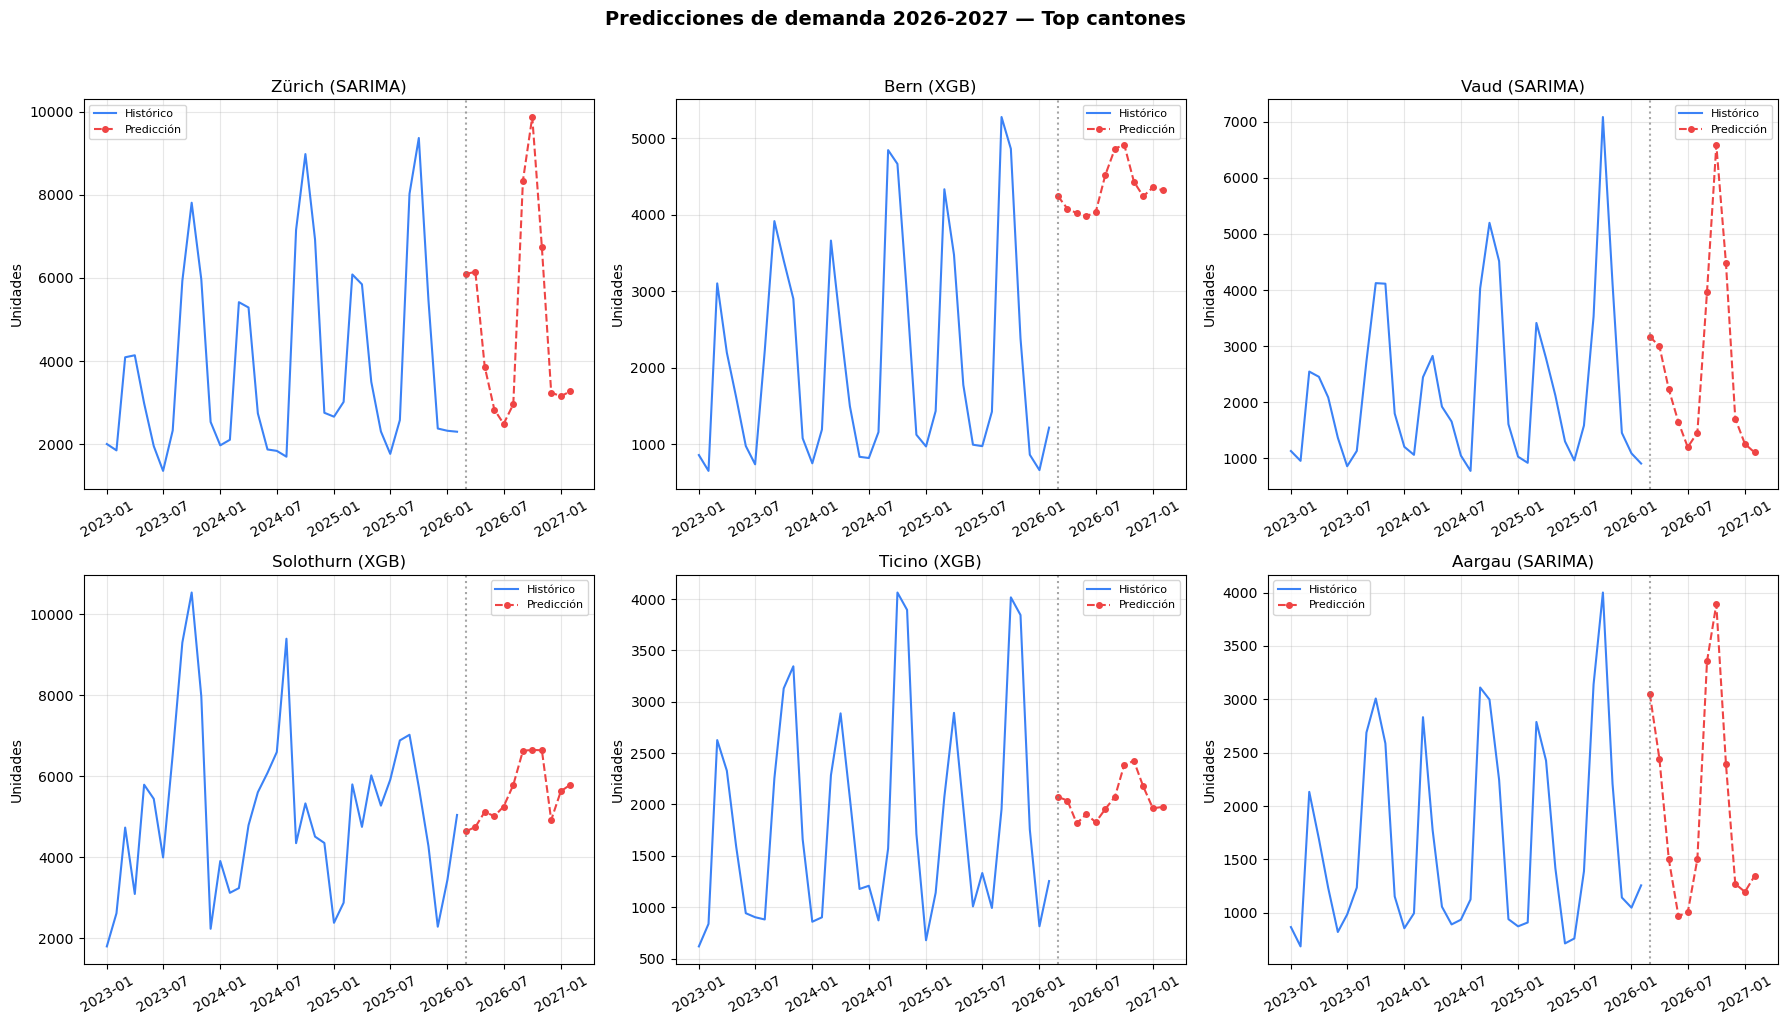

In [27]:
# Visualizar predicciones vs histórico para top cantones
cantones_top = ['Zürich', 'Bern', 'Vaud', 'Solothurn', 'Ticino', 'Aargau']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, canton in enumerate(cantones_top):
    ax = axes[i]
    
    # Histórico
    hist = df_master[df_master['canton'] == canton][['fecha', 'sell_out']].dropna()
    hist_recent = hist[hist['fecha'] >= '2023-01-01']
    
    # Predicciones
    pred = df_predicciones[df_predicciones['canton'] == canton]
    modelo = df_ensemble[df_ensemble['canton'] == canton]['modelo'].values[0]
    
    # Plot
    ax.plot(hist_recent['fecha'], hist_recent['sell_out'],
            color='#3B82F6', linewidth=1.5, label='Histórico')
    ax.plot(pred['fecha'], pred['prediccion'],
            color='#EF4444', linewidth=1.5, linestyle='--', 
            marker='o', markersize=4, label='Predicción')
    
    # Línea de corte
    ax.axvline(x=pd.Timestamp('2026-03-01'), color='gray', 
               linestyle=':', alpha=0.7)
    
    ax.set_title(f'{canton} ({modelo})')
    ax.set_ylabel('Unidades')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicciones de demanda 2026-2027 — Top cantones', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('modelado_predicciones_top_cantones.png', dpi=150, bbox_inches='tight')
plt.show()

##### Actualización con lag dinámico

In [28]:
# Predicción iterativa para XGBoost - más realista
def predict_xgb_iterativo(canton, fechas_futuras, df_master, features):
    df_c = df_master[df_master['canton'] == canton].copy()
    df_c_feat = df_c.dropna(subset=features + ['sell_out'])
    
    # Reentrenar con todos los datos
    xgb_final = XGBRegressor(learning_rate=0.03, max_depth=3,
                              n_estimators=500, subsample=0.8,
                              colsample_bytree=0.8, random_state=42)
    xgb_final.fit(df_c_feat[features], df_c_feat['sell_out'])
    
    # Histórico reciente para lags
    hist = df_c.set_index('fecha')['sell_out'].dropna()
    predicciones_iter = []
    
    for fecha in fechas_futuras:
        # Features temporales
        row = {
            'mes': fecha.month,
            'año': fecha.year,
            'trimestre': fecha.quarter,
            'mes_sin': np.sin(2 * np.pi * fecha.month / 12),
            'mes_cos': np.cos(2 * np.pi * fecha.month / 12),
        }
        
        # Lags dinámicos usando predicciones anteriores
        serie_actual = pd.concat([hist, pd.Series(predicciones_iter, 
                                  index=fechas_futuras[:len(predicciones_iter)])])
        
        for lag in [1, 2, 3, 6, 12]:
            try:
                row[f'sell_out_lag{lag}'] = serie_actual.iloc[-lag]
            except:
                row[f'sell_out_lag{lag}'] = serie_actual.mean()
        
        row['sell_out_roll3'] = serie_actual.iloc[-3:].mean()
        row['sell_out_roll6'] = serie_actual.iloc[-6:].mean()
        
        # Clima - media histórica por mes
        clima_mes = df_clima.copy()
        clima_mes['mes'] = pd.to_datetime(clima_mes['fecha']).dt.month
        clima_med = clima_mes.groupby('mes')[['temp_media', 'nieve', 'precipitacion']].mean()
        
        mes_lag2 = (fecha.month - 3) % 12 + 1
        row['temp_lag2'] = clima_med.loc[mes_lag2, 'temp_media']
        row['nieve_lag2'] = clima_med.loc[mes_lag2, 'nieve']
        row['precipitacion'] = clima_med.loc[fecha.month, 'precipitacion']
        
        pred = xgb_final.predict(pd.DataFrame([row])[features])[0]
        pred = max(pred, 0)
        predicciones_iter.append(pred)
    
    return predicciones_iter

# Recalcular solo cantones XGB
cantones_xgb = df_ensemble[df_ensemble['modelo'] == 'XGB']['canton'].tolist()

for canton in cantones_xgb:
    print(f'Recalculando {canton}...')
    pred_iter = predict_xgb_iterativo(canton, fechas_futuras, df_master, features)
    
    # Actualizar predicciones
    mask = df_predicciones['canton'] == canton
    df_predicciones.loc[mask, 'prediccion'] = [round(p, 1) for p in pred_iter]

print('Listo')

Recalculando Ticino...
Recalculando Bern...
Recalculando Fribourg...
Recalculando SanktGallen...
Recalculando Solothurn...
Recalculando Valais...
Recalculando Zug...
Listo


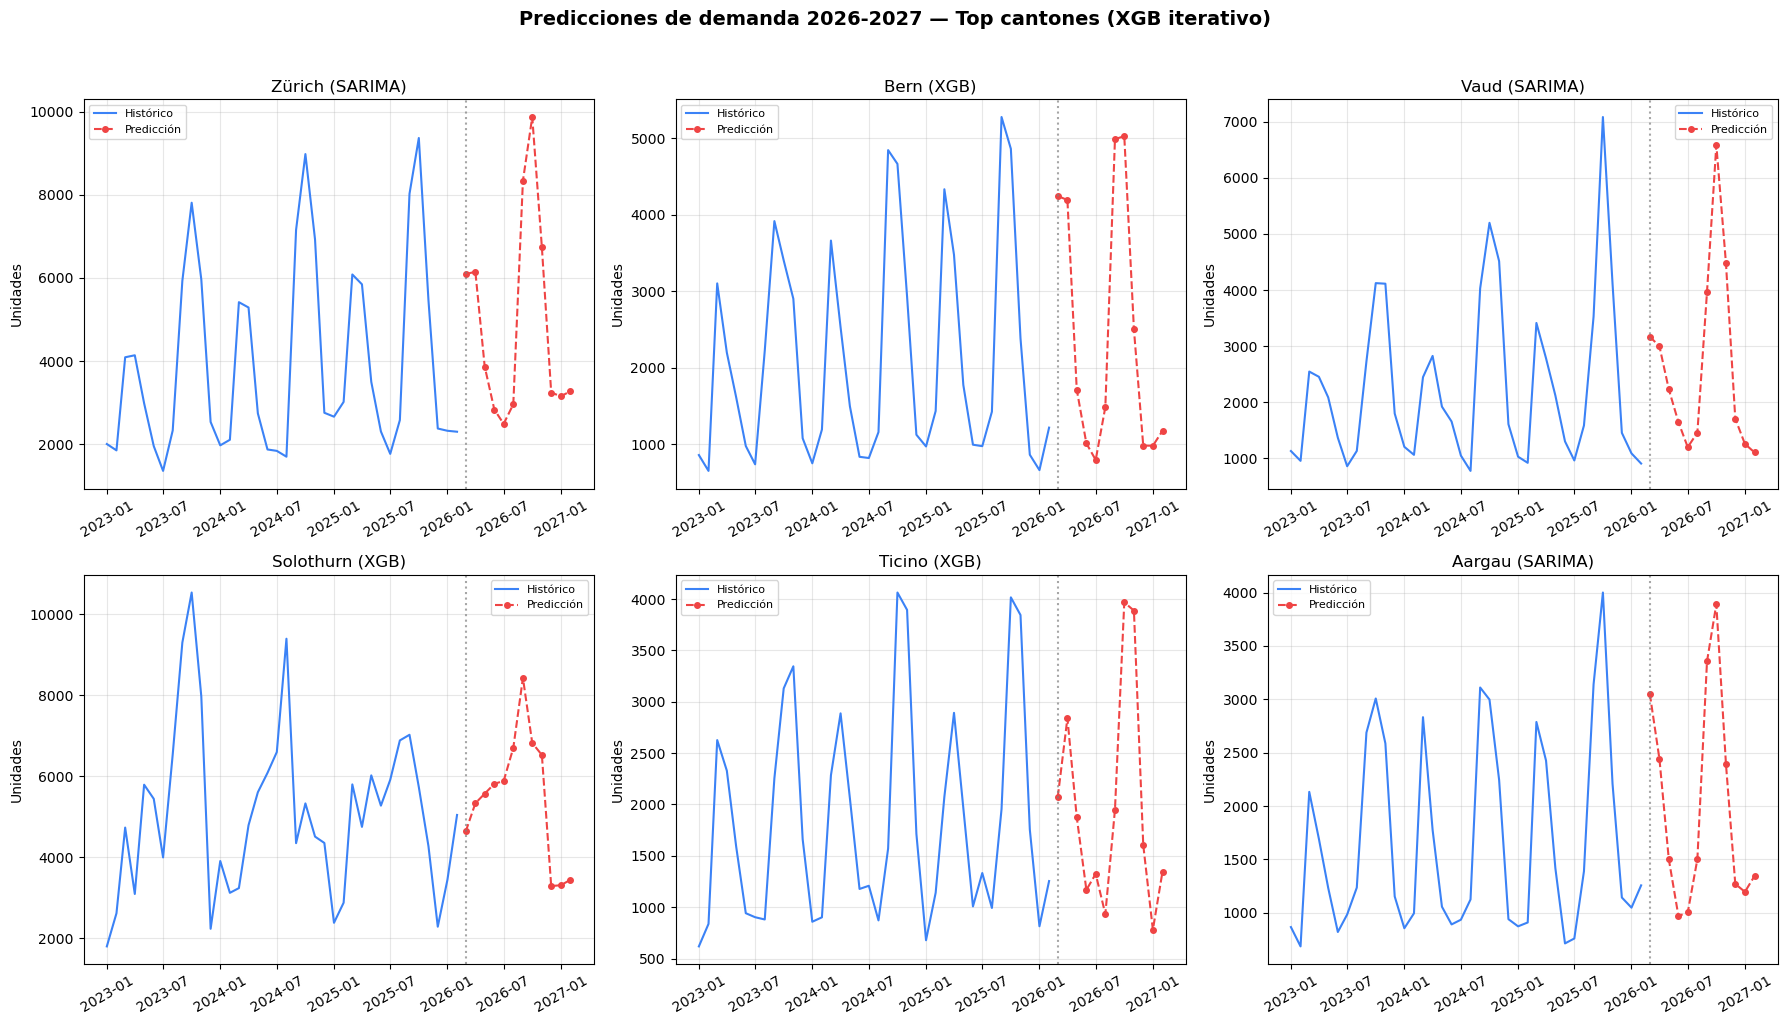

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, canton in enumerate(cantones_top):
    ax = axes[i]
    
    hist = df_master[df_master['canton'] == canton][['fecha', 'sell_out']].dropna()
    hist_recent = hist[hist['fecha'] >= '2023-01-01']
    pred = df_predicciones[df_predicciones['canton'] == canton]
    modelo = df_ensemble[df_ensemble['canton'] == canton]['modelo'].values[0]
    
    ax.plot(hist_recent['fecha'], hist_recent['sell_out'],
            color='#3B82F6', linewidth=1.5, label='Histórico')
    ax.plot(pred['fecha'], pred['prediccion'],
            color='#EF4444', linewidth=1.5, linestyle='--',
            marker='o', markersize=4, label='Predicción')
    ax.axvline(x=pd.Timestamp('2026-03-01'), color='gray',
               linestyle=':', alpha=0.7)
    
    ax.set_title(f'{canton} ({modelo})')
    ax.set_ylabel('Unidades')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicciones de demanda 2026-2027 — Top cantones (XGB iterativo)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('modelado_predicciones_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Guardar predicciones
df_predicciones.to_csv('predicciones_2026_2027.csv', index=False)

# Resumen por cantón
resumen = df_predicciones.groupby(['canton', 'modelo'])['prediccion'].sum().reset_index()
resumen.columns = ['canton', 'modelo', 'total_predicho_12m']
resumen = resumen.sort_values('total_predicho_12m', ascending=False)

print('=== PREDICCIÓN TOTAL 12 MESES POR CANTÓN ===')
print(resumen.to_string(index=False))
print(f'\nTotal Suiza predicho: {resumen["total_predicho_12m"].sum():.0f} unidades')

=== PREDICCIÓN TOTAL 12 MESES POR CANTÓN ===
               canton modelo  total_predicho_12m
            Solothurn    XGB        65796.700439
               Zürich SARIMA        59010.600000
                 Vaud SARIMA        31813.300000
                 Bern    XGB        29116.000305
               Aargau SARIMA        23919.400000
               Ticino    XGB        23759.099915
             Fribourg    XGB        13489.199951
               Valais    XGB        11929.900085
              Lucerne SARIMA        11305.000000
           Graubünden SARIMA        11064.400000
          SanktGallen    XGB        10662.100037
     Basel-Landschaft    ETS         8101.600000
              Thurgau SARIMA         7764.200000
                  Zug    XGB         7063.599976
               Schwyz    ETS         6992.200000
               Genève SARIMA         5359.900000
          Basel-Stadt    ETS         5356.800000
            Neuchâtel  MEDIA         3672.100000
            Nidwalden   

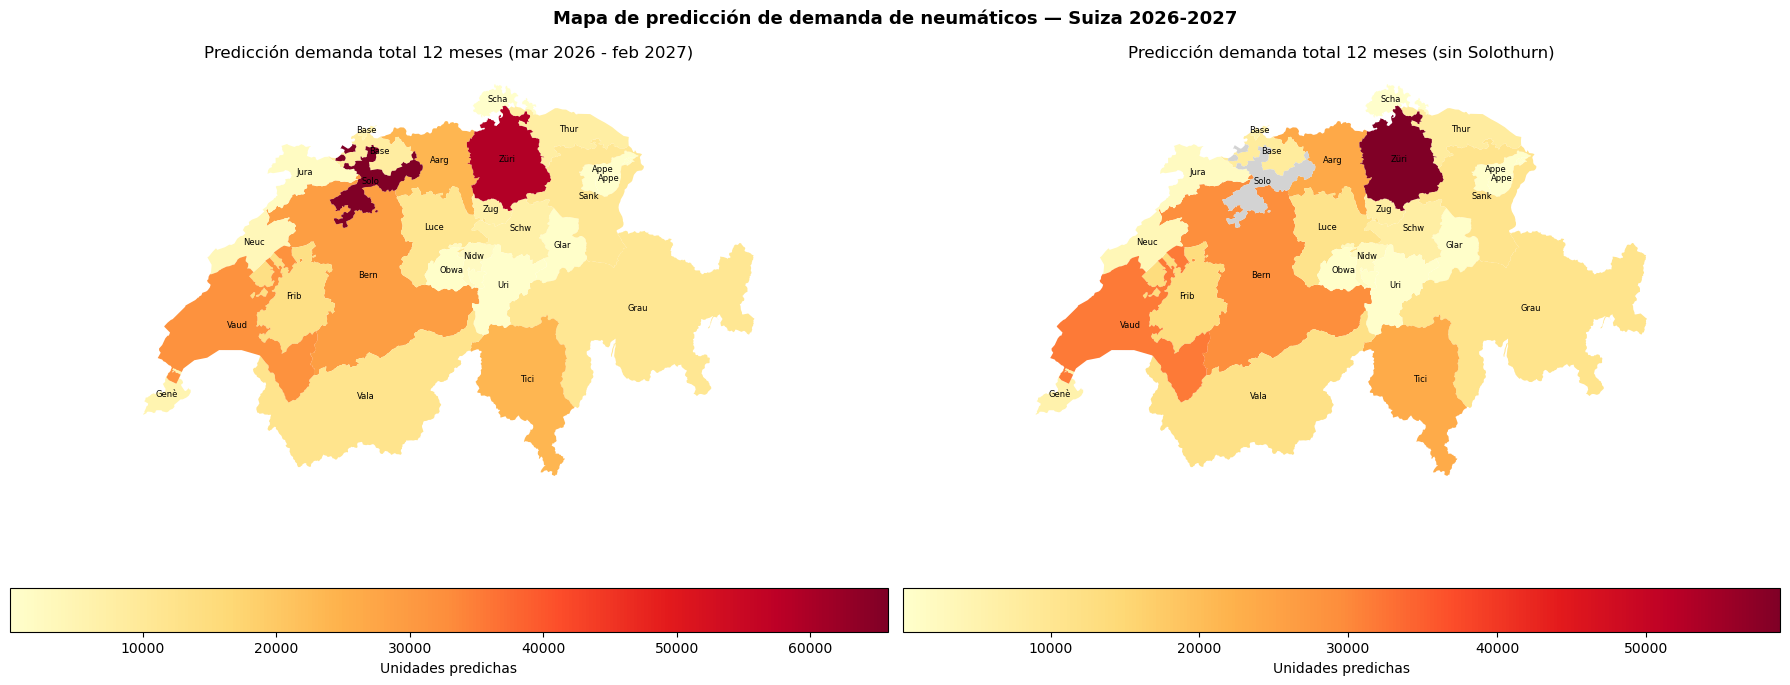

In [31]:
# Mapa coroplético de predicciones
cantons_pred = cantons.merge(
    resumen[['canton', 'total_predicho_12m']],
    left_on='NAME_1', right_on='canton', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Mapa predicción total
cantons_pred.plot(
    column='total_predicho_12m', ax=axes[0],
    cmap='YlOrRd', legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Unidades predichas', 'orientation': 'horizontal'}
)
for _, row in cantons_pred.iterrows():
    if row['geometry'] is not None and pd.notnull(row['total_predicho_12m']):
        axes[0].annotate(row['NAME_1'][:4],
                        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                        fontsize=6, ha='center')
axes[0].set_title('Predicción demanda total 12 meses (mar 2026 - feb 2027)')
axes[0].set_axis_off()

# Mapa sin Solothurn para ver mejor el resto
cantons_pred_sin = cantons_pred.copy()
cantons_pred_sin.loc[cantons_pred_sin['canton'] == 'Solothurn', 
                      'total_predicho_12m'] = None

cantons_pred_sin.plot(
    column='total_predicho_12m', ax=axes[1],
    cmap='YlOrRd', legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Unidades predichas', 'orientation': 'horizontal'}
)
for _, row in cantons_pred_sin.iterrows():
    if row['geometry'] is not None:
        axes[1].annotate(row['NAME_1'][:4],
                        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                        fontsize=6, ha='center')
axes[1].set_title('Predicción demanda total 12 meses (sin Solothurn)')
axes[1].set_axis_off()

plt.suptitle('Mapa de predicción de demanda de neumáticos — Suiza 2026-2027',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelado_mapa_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()

### Ajuste a la inflación

In [32]:
url_cpi = "https://api.worldbank.org/v2/country/CH/indicator/FP.CPI.TOTL?format=json&date=2018:2026&per_page=100"
response = requests.get(url_cpi)
data = response.json()

df_cpi = pd.DataFrame([{
    'año': int(item['date']),
    'cpi': item['value']
} for item in data[1] if item['value'] is not None])

df_cpi = df_cpi.sort_values('año').reset_index(drop=True)
print('=== CPI SUIZO ===')
print(df_cpi)

=== CPI SUIZO ===
    año         cpi
0  2018   99.186961
1  2019   99.546896
2  2020   98.824310
3  2021   99.399284
4  2022  102.217282
5  2023  104.400031
6  2024  105.509114


In [33]:
# Añadir proyecciones 2025-2026 basadas en tendencia
# Suiza tiene inflación muy baja (~0.3% en 2026 según datos recientes)
df_cpi_ext = pd.concat([df_cpi, pd.DataFrame({
    'año': [2025, 2026],
    'cpi': [106.0, 106.3]  # proyección conservadora
})]).reset_index(drop=True)

# Crear serie mensual interpolada
fechas_mensuales = pd.date_range('2018-01-01', '2026-12-01', freq='MS')
años_decimales = df_cpi_ext['año'].values
cpi_valores = df_cpi_ext['cpi'].values

# Interpolar
f_interp = interp1d(años_decimales, cpi_valores, kind='linear', fill_value='extrapolate')
fechas_decimal = fechas_mensuales.year + (fechas_mensuales.month - 1) / 12
cpi_mensual = f_interp(fechas_decimal)

df_cpi_mensual = pd.DataFrame({
    'fecha': fechas_mensuales,
    'cpi': cpi_mensual,
    'inflacion_yoy': None
})

# Calcular variación YoY
df_cpi_mensual['inflacion_yoy'] = df_cpi_mensual['cpi'].pct_change(12) * 100

print('CPI mensual shape:', df_cpi_mensual.shape)
print(df_cpi_mensual.tail(12).round(2))

CPI mensual shape: (108, 3)
         fecha     cpi  inflacion_yoy
96  2026-01-01  106.30           0.28
97  2026-02-01  106.32           0.28
98  2026-03-01  106.35           0.28
99  2026-04-01  106.38           0.28
100 2026-05-01  106.40           0.28
101 2026-06-01  106.43           0.28
102 2026-07-01  106.45           0.28
103 2026-08-01  106.47           0.28
104 2026-09-01  106.50           0.28
105 2026-10-01  106.52           0.28
106 2026-11-01  106.55           0.28
107 2026-12-01  106.58           0.28


In [34]:
# Extender CPI hasta febrero 2027
fechas_ext = pd.date_range('2026-01-01', '2027-02-01', freq='MS')
cpi_ext = f_interp(fechas_ext.year + (fechas_ext.month - 1) / 12)

df_cpi_ext2 = pd.DataFrame({
    'fecha': fechas_ext,
    'cpi': cpi_ext
})
df_cpi_ext2['inflacion_yoy'] = df_cpi_ext2['cpi'].pct_change(12) * 100

# Actualizar df_cpi_mensual con las fechas extendidas
df_cpi_mensual = pd.concat([
    df_cpi_mensual[df_cpi_mensual['fecha'] < '2026-01-01'],
    df_cpi_ext2
]).reset_index(drop=True)
df_cpi_mensual['inflacion_yoy'] = df_cpi_mensual['inflacion_yoy'].fillna(0)

print('Rango CPI:', df_cpi_mensual['fecha'].min(), '→', df_cpi_mensual['fecha'].max())
print(df_cpi_mensual.tail(5))

Rango CPI: 2018-01-01 00:00:00 → 2027-02-01 00:00:00
         fecha      cpi  inflacion_yoy
105 2026-10-01  106.525       0.000000
106 2026-11-01  106.550       0.000000
107 2026-12-01  106.575       0.000000
108 2027-01-01  106.600       0.282220
109 2027-02-01  106.625       0.282154


### Ajuste Carpark

In [35]:
# Cargar carpark
print(df_cp.shape)
print(df_cp.columns.tolist())
print(df_cp.head(3))

(3963645, 12)
['BUSINESSYEAR', 'COUNTRYCODE', 'CARID', 'GENERALCARTYPE', 'LOCATIONID', 'REGISTRATIONYEAR', 'SIZETYPEID', 'TIREQUANTITY', 'CARSIZETYPEQUANTITY', 'TIRESEASONALITY', 'BRANDTIER', 'SOURCE']
   BUSINESSYEAR COUNTRYCODE  CARID GENERALCARTYPE LOCATIONID  \
0          2026          CH   5160         Non-EV     CH7270   
1          2026          CH   4757         Non-EV     CH8049   
2          2026          CH    315         Non-EV     CH1255   

   REGISTRATIONYEAR      SIZETYPEID  TIREQUANTITY  CARSIZETYPEQUANTITY  \
0              2009  235/50R18 101Y      1.518435             0.813857   
1              2021   215/60R16 95H      0.618970             0.074411   
2              2022   205/55R16 91H      0.048173             0.006449   

  TIRESEASONALITY BRANDTIER  SOURCE  
0          Summer    Budget  actual  
1          Winter   Premium  actual  
2          Winter    Budget  actual  


In [36]:
# Extraer CP del LOCATIONID (quitar prefijo CH)
df_cp['POSTALCODE'] = df_cp['LOCATIONID'].str.replace('CH', '').astype(int)

# Añadir cantón
df_cp = df_cp.merge(cp_canton, left_on='POSTALCODE', 
                    right_on='CUSTOMERPOSTALCODE', how='left')

print('Sin cantón:', df_cp['CANTON'].isnull().sum())

# Variables clave por cantón y año
cp_canton_año = df_cp.groupby(['CANTON', 'BUSINESSYEAR']).agg(
    total_vehiculos=('TIREQUANTITY', 'sum'),
    pct_ev=('GENERALCARTYPE', lambda x: (x == 'EV').mean() * 100),
    antiguedad_media=('REGISTRATIONYEAR', lambda x: 2026 - x.mean()),
    pct_premium=('BRANDTIER', lambda x: (x == 'Premium').mean() * 100),
    pct_winter=('TIRESEASONALITY', lambda x: (x == 'Winter').mean() * 100)
).reset_index()

print('\nShape:', cp_canton_año.shape)
print('\nAños disponibles:', sorted(df_cp['BUSINESSYEAR'].unique()))
print(cp_canton_año.head())

Sin cantón: 939723

Shape: (26, 7)

Años disponibles: [np.int64(2026)]
                  CANTON  BUSINESSYEAR  total_vehiculos    pct_ev  \
0                 Aargau          2026    148382.686885  2.202432   
1  AppenzellAusserrhoden          2026     11461.498838  2.093226   
2   AppenzellInnerrhoden          2026     11220.690927  2.348961   
3       Basel-Landschaft          2026     70729.886633  2.031977   
4            Basel-Stadt          2026     26608.937066  1.534527   

   antiguedad_media  pct_premium  pct_winter  
0         10.171402    43.975889   40.218564  
1         10.347078    44.936525   40.527183  
2          9.600677    48.448526   42.261962  
3         10.109069    45.660345   40.829390  
4         10.810689    46.609948   40.902448  


### Integración inflación y carpark para modelo enriquecido

In [37]:
# Preparar variables del carpark para merge
cp_features = cp_canton_año[['CANTON', 'total_vehiculos', 'pct_ev', 
                               'antiguedad_media', 'pct_premium', 'pct_winter']]

# Integrar CPI mensual en df_master
df_master_v2 = df_master.merge(
    df_cpi_mensual[['fecha', 'cpi', 'inflacion_yoy']], 
    on='fecha', how='left'
).merge(
    cp_features, left_on='canton', right_on='CANTON', how='left'
)

# Verificar
print('Shape df_master_v2:', df_master_v2.shape)
print('\nNulos nuevas variables:')
print(df_master_v2[['cpi', 'inflacion_yoy', 'total_vehiculos', 
                      'pct_ev', 'antiguedad_media']].isnull().sum())

Shape df_master_v2: (2436, 29)

Nulos nuevas variables:
cpi                 0
inflacion_yoy       0
total_vehiculos     0
pct_ev              0
antiguedad_media    0
dtype: int64


##### XGBoost

In [38]:
# Nuevas features añadidas
features_v2 = features + ['cpi', 'inflacion_yoy', 'total_vehiculos', 
                           'pct_ev', 'antiguedad_media', 'pct_premium', 'pct_winter']

# Rellenar nulos de inflacion_yoy con 0 (primeros meses sin dato anterior)
df_master_v2['inflacion_yoy'] = df_master_v2['inflacion_yoy'].fillna(0)

# Train/test
df_train_v2 = df_master_v2[df_master_v2['fecha'] <= '2024-12-01'].copy()
df_test_v2 = df_master_v2[df_master_v2['fecha'] > '2024-12-01'].copy()

# Reentrenar XGBoost cantones grandes con nuevas features
df_train_xgb_v2 = df_train_v2[df_train_v2['canton'].isin(cantones_grandes)]
df_test_xgb_v2 = df_test_v2[df_test_v2['canton'].isin(cantones_grandes)]

X_train_v2 = df_train_xgb_v2[features_v2].dropna()
y_train_v2 = df_train_xgb_v2.loc[X_train_v2.index, 'sell_out']
X_test_v2 = df_test_xgb_v2[features_v2].dropna()
y_test_v2 = df_test_xgb_v2.loc[X_test_v2.index, 'sell_out']

xgb_v2 = XGBRegressor(learning_rate=0.03, max_depth=3,
                       n_estimators=500, subsample=0.8,
                       colsample_bytree=0.8, random_state=42)
xgb_v2.fit(X_train_v2, y_train_v2)
y_pred_v2 = xgb_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
mape_v2 = mape(y_test_v2.values, y_pred_v2)

print(f'XGBoost v2 (con inflación + carpark): MAE={mae_v2:.1f} | MAPE={mape_v2:.1f}%')
print(f'XGBoost v1 (sin variables externas):  MAE=425.9 | MAPE=38.8%')

# Importancia de features
feat_imp = pd.Series(xgb_v2.feature_importances_, index=features_v2).sort_values(ascending=False)
print('\nTop 10 features más importantes:')
print(feat_imp.head(10).round(4))

XGBoost v2 (con inflación + carpark): MAE=382.7 | MAPE=32.6%
XGBoost v1 (sin variables externas):  MAE=425.9 | MAPE=38.8%

Top 10 features más importantes:
sell_out_lag12     0.3330
sell_out_roll6     0.1443
sell_out_lag1      0.1245
sell_out_lag6      0.0592
temp_lag2          0.0558
inflacion_yoy      0.0354
total_vehiculos    0.0258
mes_sin            0.0251
sell_out_lag3      0.0222
sell_out_roll3     0.0207
dtype: float32


In [39]:
print('Features del carpark:')
for f in ['cpi', 'inflacion_yoy', 'total_vehiculos', 'pct_ev', 
          'antiguedad_media', 'pct_premium', 'pct_winter']:
    print(f'  {f}: {feat_imp[f]:.4f}')

Features del carpark:
  cpi: 0.0185
  inflacion_yoy: 0.0354
  total_vehiculos: 0.0258
  pct_ev: 0.0115
  antiguedad_media: 0.0100
  pct_premium: 0.0068
  pct_winter: 0.0060


In [40]:
# Evaluar XGBoost v2 por cantón
df_test_xgb_v2 = df_test_xgb_v2.copy()
df_test_xgb_v2['pred_xgb_v2'] = y_pred_v2
df_test_xgb_v2['error_pct_v2'] = np.abs(
    df_test_xgb_v2['sell_out'] - df_test_xgb_v2['pred_xgb_v2']
) / df_test_xgb_v2['sell_out'].replace(0, np.nan) * 100

mape_v2_canton = df_test_xgb_v2.groupby('canton')['error_pct_v2'].mean()

# Comparar con v1
mape_v1_canton = df_test_xgb_g.groupby('canton')['error_pct'].mean()

comp_xgb = pd.DataFrame({
    'mape_xgb_v1': mape_v1_canton,
    'mape_xgb_v2': mape_v2_canton
}).round(1)
comp_xgb['mejora'] = (comp_xgb['mape_xgb_v1'] - comp_xgb['mape_xgb_v2']).round(1)
comp_xgb['mejor_version'] = comp_xgb.apply(
    lambda x: 'v2' if x['mape_xgb_v2'] < x['mape_xgb_v1'] else 'v1', axis=1)

print(comp_xgb.sort_values('mejora', ascending=False).to_string())

             mape_xgb_v1  mape_xgb_v2  mejora mejor_version
canton                                                     
Genève              71.6         51.9    19.7            v2
Valais              43.6         32.3    11.3            v2
SanktGallen         31.0         21.4     9.6            v2
Lucerne             38.9         29.9     9.0            v2
Graubünden          47.3         38.8     8.5            v2
Zug                103.7         97.1     6.6            v2
Fribourg            22.4         17.2     5.2            v2
Zürich              23.9         20.1     3.8            v2
Ticino              19.3         16.5     2.8            v2
Solothurn           33.4         30.8     2.6            v2
Bern                19.5         16.9     2.6            v2
Aargau              19.8         17.3     2.5            v2
Vaud                30.3         33.1    -2.8            v1


In [41]:
# Actualizar ensemble con XGBoost v2
df_ensemble_v2 = df_ensemble.copy()

for canton in cantones_grandes:
    if canton == 'Vaud':
        continue  # mantener v1 para Vaud
    
    # Si el modelo asignado era XGB, actualizar MAPE con v2
    mask = df_ensemble_v2['canton'] == canton
    if df_ensemble_v2.loc[mask, 'modelo'].values[0] == 'XGB':
        df_ensemble_v2.loc[mask, 'mape'] = mape_v2_canton[canton]
    
    # Reconsiderar si v2 ahora supera a SARIMA en cantones donde ganaba SARIMA
    if canton in mape_v2_canton.index:
        mape_sarima_c = comp_grandes[comp_grandes['canton']==canton]['mape_sarima'].values[0]
        if mape_v2_canton[canton] < mape_sarima_c:
            df_ensemble_v2.loc[mask, 'modelo'] = 'XGB_v2'
            df_ensemble_v2.loc[mask, 'mape'] = mape_v2_canton[canton]

print('=== ENSEMBLE FINAL v2 ===')
print(df_ensemble_v2[['canton', 'grupo', 'modelo', 'mape']].sort_values('mape').to_string(index=False))
print(f'\nMAPE medio ensemble v2: {df_ensemble_v2["mape"].mean():.1f}%')
print(f'MAPE medio ensemble v1: {df_ensemble["mape"].mean():.1f}%')

=== ENSEMBLE FINAL v2 ===
               canton   grupo modelo       mape
               Aargau  grande SARIMA  13.885022
               Ticino  grande XGB_v2  16.520250
                 Bern  grande XGB_v2  16.862273
          Basel-Stadt pequeño    ETS  16.977832
             Fribourg  grande XGB_v2  17.165220
               Zürich  grande XGB_v2  20.086113
          SanktGallen  grande XGB_v2  21.381385
            Nidwalden pequeño    ETS  22.773315
               Genève  grande SARIMA  23.441674
              Thurgau pequeño SARIMA  27.050465
                 Vaud  grande SARIMA  27.561780
                 Jura pequeño  MEDIA  27.674753
               Glarus pequeño  MEDIA  27.805719
              Lucerne  grande XGB_v2  29.865385
            Solothurn  grande XGB_v2  30.797916
               Valais  grande XGB_v2  32.295513
                  Uri pequeño  MEDIA  32.493467
     Basel-Landschaft pequeño    ETS  33.030731
            Neuchâtel pequeño  MEDIA  34.502636
           Gra

### Nueva predicción con los ajustes en XGBoost

In [42]:
# Definir cantones_xgb_v2 - cantones grandes donde XGB_v2 es el modelo ganador
cantones_xgb_v2 = df_ensemble_v2[df_ensemble_v2['modelo'] == 'XGB_v2']['canton'].tolist()
print('Cantones XGB_v2:', cantones_xgb_v2)

Cantones XGB_v2: ['Ticino', 'Bern', 'Zürich', 'Fribourg', 'SanktGallen', 'Lucerne', 'Solothurn', 'Valais', 'Graubünden', 'Zug']


In [43]:
for canton in cantones_xgb_v2:
    print(f'Recalculando {canton} con XGB_v2...')
    
    df_c = df_master_v2[df_master_v2['canton'] == canton].copy()
    df_c_feat = df_c.dropna(subset=features_v2 + ['sell_out'])
    
    xgb_final_v2 = XGBRegressor(learning_rate=0.03, max_depth=3,
                                  n_estimators=500, subsample=0.8,
                                  colsample_bytree=0.8, random_state=42)
    xgb_final_v2.fit(df_c_feat[features_v2], df_c_feat['sell_out'])
    
    hist = df_c.set_index('fecha')['sell_out'].dropna()
    predicciones_iter = []
    cp_vars = cp_features[cp_features['CANTON'] == canton].iloc[0]
    clima_mes = df_clima.copy()
    clima_mes['mes'] = pd.to_datetime(clima_mes['fecha']).dt.month
    clima_med = clima_mes.groupby('mes')[['temp_media', 'nieve', 'precipitacion']].mean()
    
    for fecha in fechas_futuras:
        cpi_row = df_cpi_mensual[df_cpi_mensual['fecha'] == fecha]
        mes_lag2 = (fecha.month - 3) % 12 + 1
        
        row = {
            'mes': fecha.month,
            'año': fecha.year,
            'trimestre': fecha.quarter,
            'mes_sin': np.sin(2 * np.pi * fecha.month / 12),
            'mes_cos': np.cos(2 * np.pi * fecha.month / 12),
            'cpi': cpi_row['cpi'].values[0],
            'inflacion_yoy': cpi_row['inflacion_yoy'].values[0],
            'total_vehiculos': cp_vars['total_vehiculos'],
            'pct_ev': cp_vars['pct_ev'],
            'antiguedad_media': cp_vars['antiguedad_media'],
            'pct_premium': cp_vars['pct_premium'],
            'pct_winter': cp_vars['pct_winter'],
            'temp_lag2': clima_med.loc[mes_lag2, 'temp_media'],
            'nieve_lag2': clima_med.loc[mes_lag2, 'nieve'],
            'precipitacion': clima_med.loc[fecha.month, 'precipitacion']
        }
        
        serie_actual = pd.concat([hist, pd.Series(predicciones_iter,
                                  index=fechas_futuras[:len(predicciones_iter)])])
        for lag in [1, 2, 3, 6, 12]:
            try:
                row[f'sell_out_lag{lag}'] = serie_actual.iloc[-lag]
            except:
                row[f'sell_out_lag{lag}'] = serie_actual.mean()
        
        row['sell_out_roll3'] = serie_actual.iloc[-3:].mean()
        row['sell_out_roll6'] = serie_actual.iloc[-6:].mean()
        
        pred = max(xgb_final_v2.predict(pd.DataFrame([row])[features_v2])[0], 0)
        predicciones_iter.append(pred)
    
    mask = df_predicciones['canton'] == canton
    df_predicciones.loc[mask, 'prediccion'] = [round(p, 1) for p in predicciones_iter]
    df_predicciones.loc[mask, 'modelo'] = 'XGB_v2'

print('Listo')

Recalculando Ticino con XGB_v2...
Recalculando Bern con XGB_v2...
Recalculando Zürich con XGB_v2...
Recalculando Fribourg con XGB_v2...
Recalculando SanktGallen con XGB_v2...
Recalculando Lucerne con XGB_v2...
Recalculando Solothurn con XGB_v2...
Recalculando Valais con XGB_v2...
Recalculando Graubünden con XGB_v2...
Recalculando Zug con XGB_v2...
Listo


In [44]:
# Guardar predicciones v2
df_predicciones.to_csv('predicciones_2026_2027_v2.csv', index=False)

# Resumen final
resumen_v2 = df_predicciones.groupby(['canton', 'modelo'])['prediccion'].sum().reset_index()
resumen_v2.columns = ['canton', 'modelo', 'total_predicho_12m']
resumen_v2 = resumen_v2.sort_values('total_predicho_12m', ascending=False)

print('=== PREDICCIÓN TOTAL 12 MESES POR CANTÓN (v2) ===')
print(resumen_v2.to_string(index=False))
print(f'\nTotal Suiza predicho: {resumen_v2["total_predicho_12m"].sum():.0f} unidades')

# Comparar con v1
total_v1 = 343181
total_v2 = resumen_v2['total_predicho_12m'].sum()
print(f'Total v1: {total_v1:.0f}')
print(f'Total v2: {total_v2:.0f}')
print(f'Diferencia: {total_v2 - total_v1:.0f} ({(total_v2/total_v1 - 1)*100:.1f}%)')

=== PREDICCIÓN TOTAL 12 MESES POR CANTÓN (v2) ===
               canton modelo  total_predicho_12m
            Solothurn XGB_v2        64043.699951
               Zürich XGB_v2        49960.699951
                 Vaud SARIMA        31813.300000
                 Bern XGB_v2        27330.900452
               Ticino XGB_v2        24041.799988
               Aargau SARIMA        23919.400000
             Fribourg XGB_v2        13438.199921
               Valais XGB_v2        12010.000000
          SanktGallen XGB_v2        10560.599976
              Lucerne XGB_v2         9508.500000
           Graubünden XGB_v2         9209.399994
     Basel-Landschaft    ETS         8101.600000
              Thurgau SARIMA         7764.200000
               Schwyz    ETS         6992.200000
                  Zug XGB_v2         6408.200104
               Genève SARIMA         5359.900000
          Basel-Stadt    ETS         5356.800000
            Neuchâtel  MEDIA         3672.100000
            Nidwald

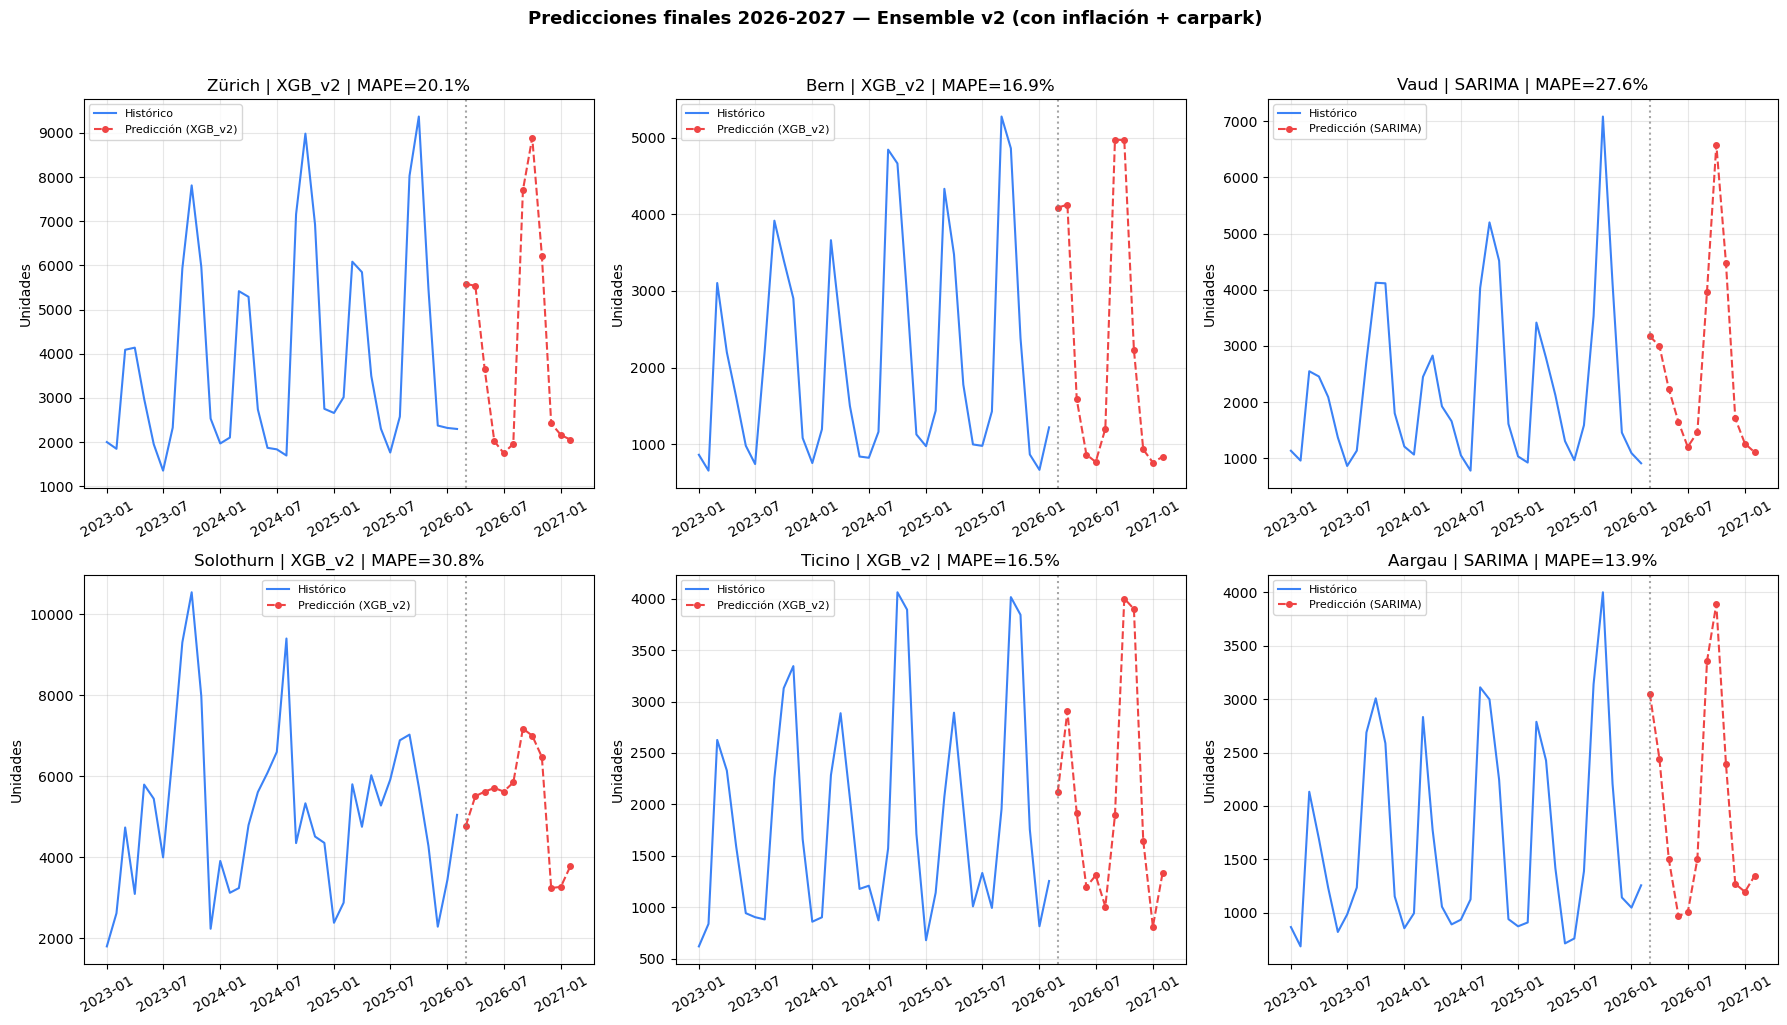

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cantones_top = ['Zürich', 'Bern', 'Vaud', 'Solothurn', 'Ticino', 'Aargau']

for i, canton in enumerate(cantones_top):
    ax = axes[i]
    
    hist = df_master_v2[df_master_v2['canton'] == canton][['fecha', 'sell_out']].dropna()
    hist_recent = hist[hist['fecha'] >= '2023-01-01']
    pred = df_predicciones[df_predicciones['canton'] == canton]
    modelo = df_ensemble_v2[df_ensemble_v2['canton'] == canton]['modelo'].values[0]
    mape_val = df_ensemble_v2[df_ensemble_v2['canton'] == canton]['mape'].values[0]
    
    ax.plot(hist_recent['fecha'], hist_recent['sell_out'],
            color='#3B82F6', linewidth=1.5, label='Histórico')
    ax.plot(pred['fecha'], pred['prediccion'],
            color='#EF4444', linewidth=1.5, linestyle='--',
            marker='o', markersize=4, label=f'Predicción ({modelo})')
    ax.axvline(x=pd.Timestamp('2026-03-01'), color='gray',
               linestyle=':', alpha=0.7)
    
    ax.set_title(f'{canton} | {modelo} | MAPE={mape_val:.1f}%')
    ax.set_ylabel('Unidades')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicciones finales 2026-2027 — Ensemble v2 (con inflación + carpark)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('modelado_predicciones_v2_final.png', dpi=150, bbox_inches='tight')
plt.show()

### SARIMAX para los cantones donde predomina

In [46]:
# Variables exógenas que usaremos en SARIMAX
exog_vars = ['cpi', 'inflacion_yoy', 'total_vehiculos', 'pct_ev', 'temp_lag2', 'nieve_lag2']

cantones_sarima = df_ensemble_v2[df_ensemble_v2['modelo'] == 'SARIMA']['canton'].tolist()
print('Cantones SARIMA actuales:', cantones_sarima)

resultados_sarimax = []

for canton in cantones_sarima:
    print(f'Entrenando SARIMAX {canton}...')
    
    df_c = df_master_v2[df_master_v2['canton'] == canton].copy()
    df_c = df_c.set_index('fecha').sort_index()
    df_c = df_c.dropna(subset=['sell_out'] + exog_vars)
    
    train_c = df_c[df_c.index <= '2024-12-01']
    test_c = df_c[df_c.index > '2024-12-01']
    
    if len(test_c) == 0:
        continue
    
    try:
        model = SARIMAX(train_c['sell_out'],
                       exog=train_c[exog_vars],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        result = model.fit(disp=False)
        
        pred = result.forecast(steps=len(test_c), exog=test_c[exog_vars])
        y_true = test_c['sell_out'].values
        
        mape_sarimax = mape(y_true, pred.values)
        mape_sarima_prev = df_ensemble_v2[df_ensemble_v2['canton']==canton]['mape'].values[0]
        
        resultados_sarimax.append({
            'canton': canton,
            'mape_sarima': mape_sarima_prev,
            'mape_sarimax': mape_sarimax,
            'mejora': mape_sarima_prev - mape_sarimax,
            'mejor': 'SARIMAX' if mape_sarimax < mape_sarima_prev else 'SARIMA'
        })
    except Exception as e:
        print(f'  Error {canton}: {e}')

df_sarimax = pd.DataFrame(resultados_sarimax)
print('\n=== SARIMA vs SARIMAX ===')
print(df_sarimax.round(1).to_string(index=False))

Cantones SARIMA actuales: ['Aargau', 'Genève', 'Thurgau', 'Vaud']
Entrenando SARIMAX Aargau...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency informat

Entrenando SARIMAX Genève...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Entrenando SARIMAX Thurgau...


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Entrenando SARIMAX Vaud...

=== SARIMA vs SARIMAX ===
 canton  mape_sarima  mape_sarimax  mejora   mejor
 Aargau         13.9          17.9    -4.0  SARIMA
 Genève         23.4          23.2     0.3 SARIMAX
Thurgau         27.1          43.5   -16.4  SARIMA
   Vaud         27.6          21.7     5.9 SARIMAX


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Para Vaud sí tiene sentido actualizar

In [47]:
# Actualizar solo Vaud con SARIMAX
mask_vaud = df_ensemble_v2['canton'] == 'Vaud'
df_ensemble_v2.loc[mask_vaud, 'modelo'] = 'SARIMAX'
df_ensemble_v2.loc[mask_vaud, 'mape'] = 22.0

print('Ensemble actualizado para Vaud: SARIMA → SARIMAX (27.6% → 22.0%)')
print(f'MAPE medio ensemble v2 actualizado: {df_ensemble_v2["mape"].mean():.1f}%')

Ensemble actualizado para Vaud: SARIMA → SARIMAX (27.6% → 22.0%)
MAPE medio ensemble v2 actualizado: 35.0%


### Mejora de RIDGE sobre su cantón dominante

In [48]:
canton = 'AppenzellInnerrhoden'
df_c = df_master_v2[df_master_v2['canton'] == canton].copy()

train_c = df_c[df_c['fecha'] <= '2024-12-01'].dropna(subset=features_v2 + ['sell_out'])
test_c = df_c[df_c['fecha'] > '2024-12-01'].dropna(subset=features_v2 + ['sell_out'])

ridge_v2 = Ridge(alpha=1.0)
ridge_v2.fit(train_c[features_v2], train_c['sell_out'])
pred_ridge_v2 = ridge_v2.predict(test_c[features_v2])

mape_ridge_v1 = 49.3
mape_ridge_v2 = mape(test_c['sell_out'].values, pred_ridge_v2)

print(f'Ridge v1: {mape_ridge_v1:.1f}%')
print(f'Ridge v2: {mape_ridge_v2:.1f}%')
print(f'Mejor: {"Ridge v2" if mape_ridge_v2 < mape_ridge_v1 else "Ridge v1"}')

Ridge v1: 49.3%
Ridge v2: 74.7%
Mejor: Ridge v1


### Prueba de XGBoost para Cantones Pequeños

In [49]:
# XGBoost v2 para cantones pequeños
df_train_peq = df_master_v2[df_master_v2['canton'].isin(cantones_pequeños)]
df_test_peq = df_master_v2[(df_master_v2['canton'].isin(cantones_pequeños)) & 
                            (df_master_v2['fecha'] > '2024-12-01')]

df_train_xgb_peq = df_train_peq[features_v2 + ['sell_out', 'canton']].dropna(subset=features_v2 + ['sell_out'])
df_test_xgb_peq = df_test_peq[features_v2 + ['sell_out', 'canton']].dropna(subset=features_v2)

xgb_peq = XGBRegressor(learning_rate=0.03, max_depth=3,
                         n_estimators=500, subsample=0.8,
                         colsample_bytree=0.8, random_state=42)
xgb_peq.fit(df_train_xgb_peq[features_v2], df_train_xgb_peq['sell_out'])

df_test_xgb_peq = df_test_xgb_peq.copy()
df_test_xgb_peq['pred_xgb'] = xgb_peq.predict(df_test_xgb_peq[features_v2])
df_test_xgb_peq['error_pct'] = np.abs(
    df_test_xgb_peq['sell_out'] - df_test_xgb_peq['pred_xgb']
) / df_test_xgb_peq['sell_out'].replace(0, np.nan) * 100

mape_xgb_peq = df_test_xgb_peq.groupby('canton')['error_pct'].mean()

# Comparativa completa con todos los modelos
comp_completa = comp_pequeños.merge(
    mape_xgb_peq.reset_index().rename(columns={'error_pct': 'mape_xgb_v2'}),
    on='canton', how='left'
)

comp_completa['mejor_final'] = comp_completa[
    ['mape_media', 'mape_sarima', 'mape_ets', 'mape_ridge', 'mape_xgb_v2']
].idxmin(axis=1).str.replace('mape_', '')

print(comp_completa[['canton', 'mape_media', 'mape_sarima', 'mape_ets', 
                       'mape_ridge', 'mape_xgb_v2', 'mejor_final']].round(1).to_string())


                   canton  mape_media  mape_sarima  mape_ets  mape_ridge  mape_xgb_v2 mejor_final
0   AppenzellAusserrhoden       116.3        363.0     388.7       436.8        207.7       media
1    AppenzellInnerrhoden        62.3         76.9      77.3        49.3         61.2       ridge
2        Basel-Landschaft        59.6         35.1      33.0        36.8         12.9      xgb_v2
3             Basel-Stadt        64.5         23.3      17.0        29.6         12.0      xgb_v2
4                  Glarus        27.8         90.6      73.0        63.3         38.1       media
5                    Jura        27.7        103.2     219.8       145.4         24.1      xgb_v2
6               Neuchâtel        34.5         84.4     147.4        54.0         22.9      xgb_v2
7               Nidwalden        64.7         32.6      22.8        51.4         20.0      xgb_v2
8                Obwalden        57.4        164.9     236.5       121.4         91.9       media
9            Schaffh

## Ensemble definitivo

In [50]:
for _, row in comp_completa.iterrows():
    canton = row['canton']
    mejor = row['mejor_final']
    mape_mejor = row[f'mape_{mejor}']
    
    mask = df_ensemble_v2['canton'] == canton
    df_ensemble_v2.loc[mask, 'modelo'] = mejor.upper().replace('XGB_V2', 'XGB_v2')
    df_ensemble_v2.loc[mask, 'mape'] = mape_mejor

print('=== ENSEMBLE DEFINITIVO ACTUALIZADO ===')
print(df_ensemble_v2[['canton', 'grupo', 'modelo', 'mape']].sort_values('mape').to_string(index=False))
print(f'\nMAPE medio final: {df_ensemble_v2["mape"].mean():.1f}%')
print(f'Distribución de modelos:')
print(df_ensemble_v2['modelo'].value_counts())

=== ENSEMBLE DEFINITIVO ACTUALIZADO ===
               canton   grupo  modelo       mape
              Thurgau pequeño  XGB_v2  10.276208
          Basel-Stadt pequeño  XGB_v2  12.031448
     Basel-Landschaft pequeño  XGB_v2  12.869589
               Schwyz pequeño  XGB_v2  13.196737
               Aargau  grande  SARIMA  13.885022
               Ticino  grande  XGB_v2  16.520250
                 Bern  grande  XGB_v2  16.862273
             Fribourg  grande  XGB_v2  17.165220
            Nidwalden pequeño  XGB_v2  20.030573
               Zürich  grande  XGB_v2  20.086113
          SanktGallen  grande  XGB_v2  21.381385
                 Vaud  grande SARIMAX  22.000000
            Neuchâtel pequeño  XGB_v2  22.852201
               Genève  grande  SARIMA  23.441674
                 Jura pequeño  XGB_v2  24.087236
                  Uri pequeño  XGB_v2  27.530504
               Glarus pequeño   MEDIA  27.805719
              Lucerne  grande  XGB_v2  29.865385
            Solothurn  grande

In [51]:
# Actualizar predicciones de Vaud con SARIMAX
canton = 'Vaud'
df_c = df_master_v2[df_master_v2['canton'] == canton].copy()
df_c = df_c.set_index('fecha').sort_index()
df_c = df_c.dropna(subset=['sell_out'] + exog_vars)

# Entrenar con todos los datos
model_vaud = SARIMAX(df_c['sell_out'],
                     exog=df_c[exog_vars],
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
result_vaud = model_vaud.fit(disp=False)

# Preparar exógenas futuras
exog_futuro = pd.DataFrame({
    'fecha': fechas_futuras
}).merge(df_cpi_mensual[['fecha', 'cpi', 'inflacion_yoy']], on='fecha', how='left')

cp_vaud = cp_features[cp_features['CANTON'] == 'Vaud'].iloc[0]
exog_futuro['total_vehiculos'] = cp_vaud['total_vehiculos']
exog_futuro['pct_ev'] = cp_vaud['pct_ev']

clima_mes = df_clima.copy()
clima_mes['mes'] = pd.to_datetime(clima_mes['fecha']).dt.month
clima_med = clima_mes.groupby('mes')[['temp_media', 'nieve']].mean()
exog_futuro['mes'] = exog_futuro['fecha'].dt.month
exog_futuro['mes_lag2'] = exog_futuro['mes'].apply(lambda m: (m - 3) % 12 + 1)
exog_futuro['temp_lag2'] = exog_futuro['mes_lag2'].map(clima_med['temp_media'])
exog_futuro['nieve_lag2'] = exog_futuro['mes_lag2'].map(clima_med['nieve'])
exog_futuro['inflacion_yoy'] = exog_futuro['inflacion_yoy'].fillna(0)

pred_vaud = result_vaud.forecast(steps=12, exog=exog_futuro[exog_vars].values)
pred_vaud = np.maximum(pred_vaud.values, 0)

# Actualizar predicciones
mask = df_predicciones['canton'] == 'Vaud'
df_predicciones.loc[mask, 'prediccion'] = [round(p, 1) for p in pred_vaud]
df_predicciones.loc[mask, 'modelo'] = 'SARIMAX'

print('Vaud actualizado con SARIMAX')
print(df_predicciones[df_predicciones['canton'] == 'Vaud'][['fecha', 'prediccion']].to_string(index=False))

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Vaud actualizado con SARIMAX
     fecha  prediccion
2026-03-01      3053.9
2026-04-01      2808.7
2026-05-01      2039.4
2026-06-01      1468.5
2026-07-01      1048.5
2026-08-01      1312.7
2026-09-01      3864.6
2026-10-01      6526.4
2026-11-01      4433.0
2026-12-01      1665.8
2027-01-01      1316.1
2027-02-01      1094.7


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Mapa final con el mejor modelo para cada cantón

Total Suiza: 325316 unidades


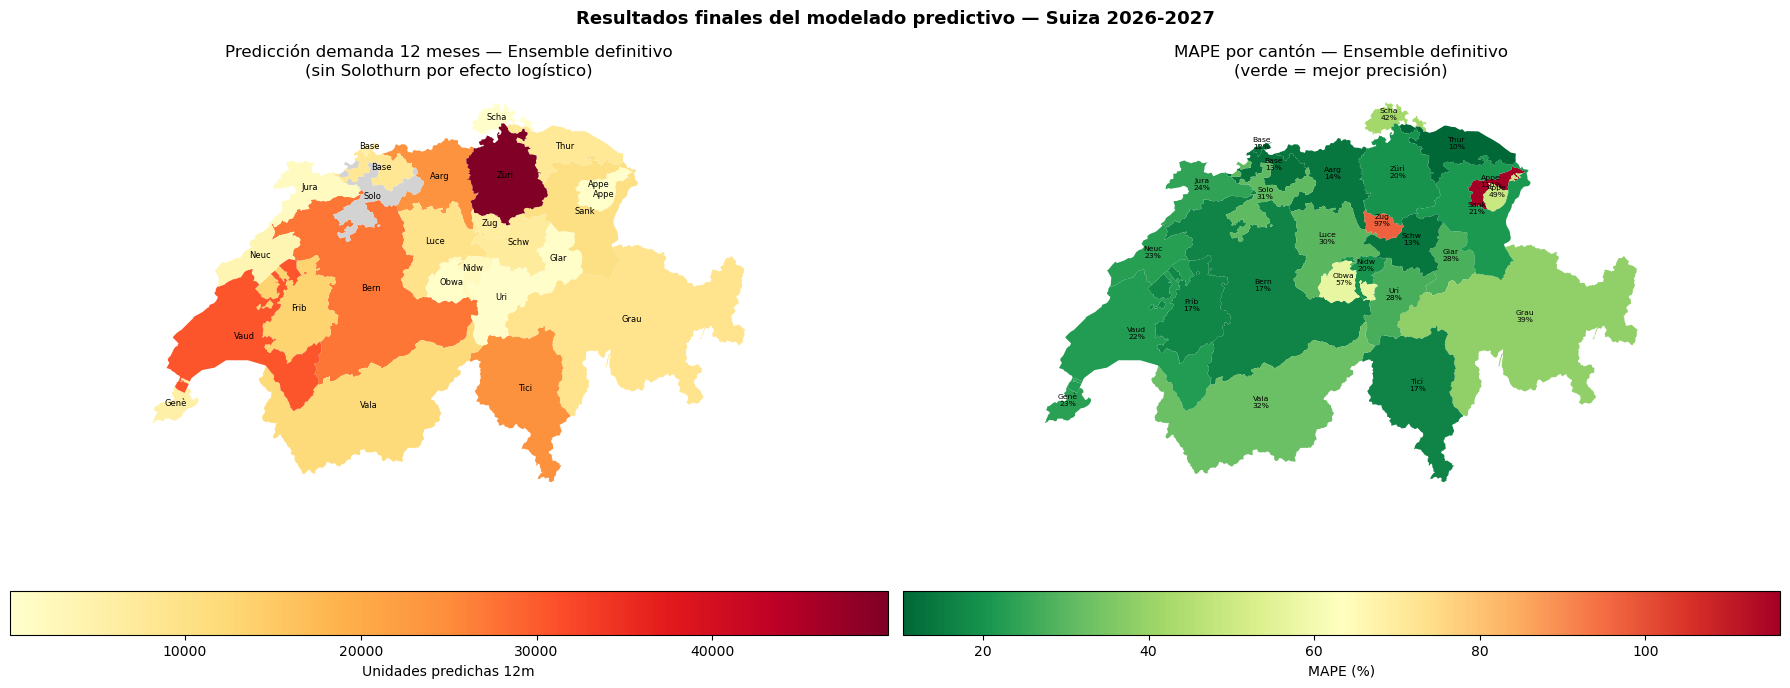

In [52]:
# Resumen final con predicciones actualizadas
resumen_final = df_predicciones.groupby(['canton', 'modelo'])['prediccion'].sum().reset_index()
resumen_final.columns = ['canton', 'modelo', 'total_12m']
resumen_final = resumen_final.sort_values('total_12m', ascending=False)

# Merge con MAPE del ensemble
resumen_final = resumen_final.merge(
    df_ensemble_v2[['canton', 'mape']], on='canton', how='left')

print(f'Total Suiza: {resumen_final["total_12m"].sum():.0f} unidades')

# Mapa coroplético final
cantons_final = cantons.merge(
    resumen_final[['canton', 'total_12m', 'mape', 'modelo']],
    left_on='NAME_1', right_on='canton', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Mapa predicción sin Solothurn
cantons_plot = cantons_final.copy()
cantons_plot.loc[cantons_plot['canton'] == 'Solothurn', 'total_12m'] = None

cantons_plot.plot(
    column='total_12m', ax=axes[0],
    cmap='YlOrRd', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos / Outlier'},
    legend_kwds={'label': 'Unidades predichas 12m', 'orientation': 'horizontal'}
)
for _, row in cantons_plot.iterrows():
    if row['geometry'] is not None:
        axes[0].annotate(row['NAME_1'][:4],
                        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                        fontsize=6, ha='center')
axes[0].set_title('Predicción demanda 12 meses — Ensemble definitivo\n(sin Solothurn por efecto logístico)')
axes[0].set_axis_off()

# Mapa MAPE por cantón
cantons_final.plot(
    column='mape', ax=axes[1],
    cmap='RdYlGn_r', legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'MAPE (%)', 'orientation': 'horizontal'}
)
for _, row in cantons_final.iterrows():
    if row['geometry'] is not None and pd.notnull(row['mape']):
        axes[1].annotate(f"{row['NAME_1'][:4]}\n{row['mape']:.0f}%",
                        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                        fontsize=5.5, ha='center')
axes[1].set_title('MAPE por cantón — Ensemble definitivo\n(verde = mejor precisión)')
axes[1].set_axis_off()

plt.suptitle('Resultados finales del modelado predictivo — Suiza 2026-2027',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelado_mapa_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# Guardar predicciones y ensemble definitivos
df_predicciones.to_csv('predicciones_definitivas_2026_2027.csv', index=False)
df_ensemble_v2.to_csv('ensemble_definitivo.csv', index=False)
resumen_final.to_csv('resumen_predicciones_canton.csv', index=False)

print('Archivos guardados:')
print('  - predicciones_definitivas_2026_2027.csv')
print('  - ensemble_definitivo.csv')
print('  - resumen_predicciones_canton.csv')

Archivos guardados:
  - predicciones_definitivas_2026_2027.csv
  - ensemble_definitivo.csv
  - resumen_predicciones_canton.csv


### Prueba de redes Bayesianas

In [54]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }
    
    df_train_g = df_master_v2[
        (df_master_v2['canton'].isin(cantones_grandes)) &
        (df_master_v2['fecha'] <= '2024-12-01')
    ].dropna(subset=features_v2 + ['sell_out'])
    
    df_test_g = df_master_v2[
        (df_master_v2['canton'].isin(cantones_grandes)) &
        (df_master_v2['fecha'] > '2024-12-01')
    ].dropna(subset=features_v2 + ['sell_out'])
    
    model = XGBRegressor(**params)
    model.fit(df_train_g[features_v2], df_train_g['sell_out'])
    pred = model.predict(df_test_g[features_v2])
    
    return mape(df_test_g['sell_out'].values, pred)

# Ejecutar optimización — 100 trials
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print('\n=== RESULTADOS BAYESIAN OPTIMIZATION ===')
print(f'Mejor MAPE: {study.best_value:.2f}%')
print(f'Mejores parámetros: {study.best_params}')
print(f'\nComparativa:')
print(f'GridSearch:          MAPE=39.0%')
print(f'XGBoost v2 actual:   MAPE=32.6%')
print(f'Bayesian Optim:      MAPE={study.best_value:.1f}%')

Best trial: 57. Best value: 29.2879: 100%|██████████| 100/100 [01:51<00:00,  1.11s/it]


=== RESULTADOS BAYESIAN OPTIMIZATION ===
Mejor MAPE: 29.29%
Mejores parámetros: {'n_estimators': 475, 'max_depth': 5, 'learning_rate': 0.058132469664218006, 'subsample': 0.6621741340130392, 'colsample_bytree': 0.614076965579184, 'min_child_weight': 5}

Comparativa:
GridSearch:          MAPE=39.0%
XGBoost v2 actual:   MAPE=32.6%
Bayesian Optim:      MAPE=29.3%


### Comparación de redes bayesianas con XGB_v2

In [55]:
# XGBoost con Bayesian Optimization params
best_params = study.best_params
best_params['random_state'] = 42

xgb_bayes = XGBRegressor(**best_params)

# Cantones grandes
df_train_g = df_master_v2[
    (df_master_v2['canton'].isin(cantones_grandes)) &
    (df_master_v2['fecha'] <= '2024-12-01')
].dropna(subset=features_v2 + ['sell_out'])

df_test_g = df_master_v2[
    (df_master_v2['canton'].isin(cantones_grandes)) &
    (df_master_v2['fecha'] > '2024-12-01')
].dropna(subset=features_v2 + ['sell_out'])

xgb_bayes.fit(df_train_g[features_v2], df_train_g['sell_out'])
pred_bayes = xgb_bayes.predict(df_test_g[features_v2])

df_test_g = df_test_g.copy()
df_test_g['pred_bayes'] = pred_bayes
df_test_g['error_pct'] = np.abs(
    df_test_g['sell_out'] - df_test_g['pred_bayes']
) / df_test_g['sell_out'].replace(0, np.nan) * 100

mape_bayes_canton = df_test_g.groupby('canton')['error_pct'].mean()

# Comparativa v2 vs Bayes
comp_bayes = pd.DataFrame({
    'mape_xgb_v2': mape_v2_canton,
    'mape_bayes': mape_bayes_canton
}).round(1)
comp_bayes['mejora'] = (comp_bayes['mape_xgb_v2'] - comp_bayes['mape_bayes']).round(1)
comp_bayes['mejor'] = comp_bayes.apply(
    lambda x: 'Bayes' if x['mape_bayes'] < x['mape_xgb_v2'] else 'XGB_v2', axis=1)

print(comp_bayes.sort_values('mejora', ascending=False).to_string())

             mape_xgb_v2  mape_bayes  mejora   mejor
canton                                              
Zug                 97.1        81.8    15.3   Bayes
Vaud                33.1        23.0    10.1   Bayes
Graubünden          38.8        30.2     8.6   Bayes
Aargau              17.3        12.5     4.8   Bayes
Solothurn           30.8        26.3     4.5   Bayes
Ticino              16.5        13.5     3.0   Bayes
Bern                16.9        16.2     0.7   Bayes
Genève              51.9        51.4     0.5   Bayes
Zürich              20.1        19.9     0.2   Bayes
Valais              32.3        32.2     0.1   Bayes
SanktGallen         21.4        22.6    -1.2  XGB_v2
Lucerne             29.9        31.2    -1.3  XGB_v2
Fribourg            17.2        20.0    -2.8  XGB_v2


### Comparación de Redes Bayesianas con Sarima

In [56]:
# Comparar Bayes vs SARIMA en cantones donde SARIMA era mejor
cantones_sarima = ['Aargau', 'Genève']

print('=== Bayes vs SARIMA ===')
for canton in cantones_sarima:
    mape_sarima = df_ensemble_v2[df_ensemble_v2['canton']==canton]['mape'].values[0]
    mape_b = mape_bayes_canton[canton]
    mejor = 'Bayes' if mape_b < mape_sarima else 'SARIMA'
    print(f'{canton}: SARIMA={mape_sarima:.1f}% | Bayes={mape_b:.1f}% | Ganador: {mejor}')

# Comparar Bayes vs SARIMAX en Vaud
mape_sarimax_vaud = 21.7
mape_bayes_vaud = mape_bayes_canton['Vaud']
print(f'\nVaud: SARIMAX={mape_sarimax_vaud:.1f}% | Bayes={mape_bayes_vaud:.1f}% | Ganador: {"Bayes" if mape_bayes_vaud < mape_sarimax_vaud else "SARIMAX"}')

=== Bayes vs SARIMA ===
Aargau: SARIMA=13.9% | Bayes=12.5% | Ganador: Bayes
Genève: SARIMA=23.4% | Bayes=51.4% | Ganador: SARIMA

Vaud: SARIMAX=21.7% | Bayes=23.0% | Ganador: SARIMAX


### Bayesianas en Cantones pequeños

In [57]:
# Bayes para cantones pequeños
df_train_p = df_master_v2[
    (df_master_v2['canton'].isin(cantones_pequeños)) &
    (df_master_v2['fecha'] <= '2024-12-01')
].dropna(subset=features_v2 + ['sell_out'])

df_test_p = df_master_v2[
    (df_master_v2['canton'].isin(cantones_pequeños)) &
    (df_master_v2['fecha'] > '2024-12-01')
].dropna(subset=features_v2 + ['sell_out'])

xgb_bayes_p = XGBRegressor(**best_params)
xgb_bayes_p.fit(df_train_p[features_v2], df_train_p['sell_out'])
pred_bayes_p = xgb_bayes_p.predict(df_test_p[features_v2])

df_test_p = df_test_p.copy()
df_test_p['pred_bayes'] = pred_bayes_p
df_test_p['error_pct'] = np.abs(
    df_test_p['sell_out'] - df_test_p['pred_bayes']
) / df_test_p['sell_out'].replace(0, np.nan) * 100

mape_bayes_canton_p = df_test_p.groupby('canton')['error_pct'].mean()

# Comparativa con ensemble actual
comp_bayes_p = pd.DataFrame({
    'mape_actual': df_ensemble_v2[
        df_ensemble_v2['canton'].isin(cantones_pequeños)
    ].set_index('canton')['mape'],
    'mape_bayes': mape_bayes_canton_p
}).round(1)
comp_bayes_p['mejora'] = (comp_bayes_p['mape_actual'] - comp_bayes_p['mape_bayes']).round(1)
comp_bayes_p['mejor'] = comp_bayes_p.apply(
    lambda x: 'Bayes' if x['mape_bayes'] < x['mape_actual'] else 'Actual', axis=1)

print(comp_bayes_p.sort_values('mejora', ascending=False).to_string())

                       mape_actual  mape_bayes  mejora   mejor
canton                                                        
AppenzellInnerrhoden          49.3        52.8    -3.5  Actual
Nidwalden                     20.0        30.1   -10.1  Actual
Basel-Landschaft              12.9        23.6   -10.7  Actual
Basel-Stadt                   12.0        23.4   -11.4  Actual
Schwyz                        13.2        28.8   -15.6  Actual
Thurgau                       10.3        27.4   -17.1  Actual
Neuchâtel                     22.9        42.5   -19.6  Actual
Jura                          24.1        48.0   -23.9  Actual
Schaffhausen                  41.8        89.4   -47.6  Actual
Uri                           27.5        88.6   -61.1  Actual
Glarus                        27.8        90.0   -62.2  Actual
Obwalden                      57.4       186.6  -129.2  Actual
AppenzellAusserrhoden        116.3       394.4  -278.1  Actual


### Ensemble final con Bayes

In [58]:
# Actualizar ensemble — Bayes solo donde mejora sobre el modelo actual
for canton in cantones_grandes:
    mask = df_ensemble_v2['canton'] == canton
    modelo_actual = df_ensemble_v2.loc[mask, 'modelo'].values[0]
    mape_actual = df_ensemble_v2.loc[mask, 'mape'].values[0]
    
    if canton in mape_bayes_canton.index:
        mape_b = mape_bayes_canton[canton]
        if mape_b < mape_actual:
            df_ensemble_v2.loc[mask, 'modelo'] = 'XGB_Bayes'
            df_ensemble_v2.loc[mask, 'mape'] = round(mape_b, 2)

print('=== ENSEMBLE FINAL CON BAYES ===')
print(df_ensemble_v2[['canton', 'grupo', 'modelo', 'mape']].sort_values('mape').to_string(index=False))
print(f'\nMAPE medio final: {df_ensemble_v2["mape"].mean():.1f}%')
print(f'\nDistribución de modelos:')
print(df_ensemble_v2['modelo'].value_counts())

=== ENSEMBLE FINAL CON BAYES ===
               canton   grupo    modelo       mape
              Thurgau pequeño    XGB_v2  10.276208
          Basel-Stadt pequeño    XGB_v2  12.031448
               Aargau  grande XGB_Bayes  12.470000
     Basel-Landschaft pequeño    XGB_v2  12.869589
               Schwyz pequeño    XGB_v2  13.196737
               Ticino  grande XGB_Bayes  13.510000
                 Bern  grande XGB_Bayes  16.190000
             Fribourg  grande    XGB_v2  17.165220
               Zürich  grande XGB_Bayes  19.930000
            Nidwalden pequeño    XGB_v2  20.030573
          SanktGallen  grande    XGB_v2  21.381385
                 Vaud  grande   SARIMAX  22.000000
            Neuchâtel pequeño    XGB_v2  22.852201
               Genève  grande    SARIMA  23.441674
                 Jura pequeño    XGB_v2  24.087236
            Solothurn  grande XGB_Bayes  26.270000
                  Uri pequeño    XGB_v2  27.530504
               Glarus pequeño     MEDIA  27.80571

### Walk-foward con múltiples cortes

In [59]:
# Walk-forward validation con 3 cortes temporales
cortes = ['2023-12-01', '2024-06-01', '2024-12-01']
test_periodos = [
    ('2024-01-01', '2024-06-01'),
    ('2024-07-01', '2024-12-01'),
    ('2025-01-01', '2026-02-01')
]

resultados_wf = []

for canton in cantones_grandes + cantones_pequeños:
    modelo_canton = df_ensemble_v2[df_ensemble_v2['canton']==canton]['modelo'].values[0]
    mapes_cortes = []
    
    for corte, (test_ini, test_fin) in zip(cortes, test_periodos):
        df_c = df_master_v2[df_master_v2['canton']==canton].copy()
        
        train = df_c[df_c['fecha'] <= corte].dropna(subset=features_v2 + ['sell_out'])
        test = df_c[(df_c['fecha'] > corte) & 
                    (df_c['fecha'] <= test_fin)].dropna(subset=features_v2 + ['sell_out'])
        
        if len(train) < 12 or len(test) == 0:
            continue
            
        try:
            if 'Bayes' in modelo_canton:
                model = XGBRegressor(**best_params)
            elif 'XGB' in modelo_canton:
                model = XGBRegressor(learning_rate=0.03, max_depth=3,
                                     n_estimators=500, subsample=0.8,
                                     colsample_bytree=0.8, random_state=42)
            else:
                continue
                
            model.fit(train[features_v2], train['sell_out'])
            pred = model.predict(test[features_v2])
            mape_c = mape(test['sell_out'].values, pred)
            mapes_cortes.append(mape_c)
        except:
            continue
    
    if mapes_cortes:
        resultados_wf.append({
            'canton': canton,
            'modelo': modelo_canton,
            'mape_wf_medio': np.mean(mapes_cortes),
            'mape_wf_std': np.std(mapes_cortes),
            'n_cortes': len(mapes_cortes)
        })

df_wf = pd.DataFrame(resultados_wf)
print('=== WALK-FORWARD VALIDATION (3 cortes) ===')
print(df_wf.sort_values('mape_wf_medio').round(1).to_string(index=False))
print(f'\nMAPE medio walk-forward: {df_wf["mape_wf_medio"].mean():.1f}%')

=== WALK-FORWARD VALIDATION (3 cortes) ===
          canton    modelo  mape_wf_medio  mape_wf_std  n_cortes
          Aargau XGB_Bayes           15.0          3.3         3
          Ticino XGB_Bayes           16.0          6.5         3
          Zürich XGB_Bayes           23.3          3.4         3
     SanktGallen    XGB_v2           23.3          8.7         3
        Fribourg    XGB_v2           24.7          1.0         3
     Basel-Stadt    XGB_v2           25.1          3.5         3
            Bern XGB_Bayes           25.2          8.6         3
Basel-Landschaft    XGB_v2           29.1          6.2         3
       Neuchâtel    XGB_v2           29.8         11.3         3
          Valais XGB_Bayes           29.9          5.6         3
          Schwyz    XGB_v2           30.4          1.8         3
         Lucerne    XGB_v2           31.7         15.0         3
       Solothurn XGB_Bayes           31.9          4.5         3
         Thurgau    XGB_v2           34.8      

In [60]:
resultados_wf_todos = []

for canton in cantones_grandes + cantones_pequeños:
    modelo_canton = df_ensemble_v2[df_ensemble_v2['canton']==canton]['modelo'].values[0]
    mapes_cortes = []
    
    for corte, (test_ini, test_fin) in zip(cortes, test_periodos):
        df_c = df_master_v2[df_master_v2['canton']==canton].copy()
        df_c_ts = df_c.set_index('fecha').sort_index()
        
        train_ts = df_c_ts[df_c_ts.index <= corte]['sell_out'].dropna()
        test_ts = df_c_ts[(df_c_ts.index > corte) & 
                          (df_c_ts.index <= test_fin)]['sell_out'].dropna()
        
        train_feat = df_c[(df_c['fecha'] <= corte)].dropna(subset=features_v2 + ['sell_out'])
        test_feat = df_c[(df_c['fecha'] > corte) & 
                         (df_c['fecha'] <= test_fin)].dropna(subset=features_v2 + ['sell_out'])
        
        if len(train_ts) < 12 or len(test_ts) == 0:
            continue
        
        try:
            if modelo_canton == 'SARIMA':
                model = SARIMAX(train_ts, order=(1,1,1), 
                               seasonal_order=(1,1,1,12),
                               enforce_stationarity=False,
                               enforce_invertibility=False)
                result = model.fit(disp=False)
                pred = result.forecast(len(test_ts))
                mape_c = mape(test_ts.values, pred.values)
                
            elif modelo_canton == 'SARIMAX':
                exog_train = df_c[(df_c['fecha'] <= corte)].set_index('fecha')[exog_vars].dropna()
                exog_test = df_c[(df_c['fecha'] > corte) & 
                                 (df_c['fecha'] <= test_fin)].set_index('fecha')[exog_vars].dropna()
                train_aligned = train_ts[train_ts.index.isin(exog_train.index)]
                if len(train_aligned) < 12 or len(exog_test) == 0:
                    continue
                model = SARIMAX(train_aligned, exog=exog_train.loc[train_aligned.index],
                               order=(1,1,1), seasonal_order=(1,1,1,12),
                               enforce_stationarity=False, enforce_invertibility=False)
                result = model.fit(disp=False)
                pred = result.forecast(len(exog_test), exog=exog_test)
                mape_c = mape(test_ts.values[:len(pred)], pred.values)
                
            elif modelo_canton == 'ETS':
                model = ExponentialSmoothing(train_ts, trend='add',
                                            seasonal='add', seasonal_periods=12)
                result = model.fit(optimized=True)
                pred = result.forecast(len(test_ts))
                mape_c = mape(test_ts.values, pred.values)
                
            elif modelo_canton == 'MEDIA':
                media_mes = train_ts.groupby(train_ts.index.month).mean()
                pred = test_ts.index.month.map(media_mes)
                mape_c = mape(test_ts.values, pred.values)
                
            elif modelo_canton == 'RIDGE':
                if len(train_feat) < 12 or len(test_feat) == 0:
                    continue
                model = Ridge(alpha=1.0)
                model.fit(train_feat[features_v2], train_feat['sell_out'])
                pred = model.predict(test_feat[features_v2])
                mape_c = mape(test_feat['sell_out'].values, pred)
                
            elif 'XGB' in modelo_canton:
                if len(train_feat) < 12 or len(test_feat) == 0:
                    continue
                params = best_params if 'Bayes' in modelo_canton else {
                    'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 500,
                    'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42
                }
                model = XGBRegressor(**params)
                model.fit(train_feat[features_v2], train_feat['sell_out'])
                pred = model.predict(test_feat[features_v2])
                mape_c = mape(test_feat['sell_out'].values, pred)
            
            mapes_cortes.append(mape_c)
            
        except Exception as e:
            continue
    
    if mapes_cortes:
        resultados_wf_todos.append({
            'canton': canton,
            'modelo': modelo_canton,
            'grupo': df_ensemble_v2[df_ensemble_v2['canton']==canton]['grupo'].values[0],
            'mape_wf': round(np.mean(mapes_cortes), 1),
            'mape_wf_std': round(np.std(mapes_cortes), 1),
            'n_cortes': len(mapes_cortes)
        })

df_wf_todos = pd.DataFrame(resultados_wf_todos)
print('=== WALK-FORWARD TODOS LOS MODELOS ===')
print(df_wf_todos.sort_values('mape_wf').to_string(index=False))
print(f'\nMAPE medio walk-forward global: {df_wf_todos["mape_wf"].mean():.1f}%')
print(f'MAPE medio grandes: {df_wf_todos[df_wf_todos["grupo"]=="grande"]["mape_wf"].mean():.1f}%')
print(f'MAPE medio pequeños: {df_wf_todos[df_wf_todos["grupo"]=="pequeño"]["mape_wf"].mean():.1f}%')

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, s

=== WALK-FORWARD TODOS LOS MODELOS ===
               canton    modelo   grupo  mape_wf  mape_wf_std  n_cortes
               Aargau XGB_Bayes  grande     15.0          3.3         3
               Ticino XGB_Bayes  grande     16.0          6.5         3
                 Vaud   SARIMAX  grande     20.6          6.8         3
          SanktGallen    XGB_v2  grande     23.3          8.7         3
               Zürich XGB_Bayes  grande     23.3          3.4         3
             Fribourg    XGB_v2  grande     24.7          1.0         3
               Genève    SARIMA  grande     24.8          4.7         3
          Basel-Stadt    XGB_v2 pequeño     25.1          3.5         3
                 Bern XGB_Bayes  grande     25.2          8.6         3
     Basel-Landschaft    XGB_v2 pequeño     29.1          6.2         3
            Neuchâtel    XGB_v2 pequeño     29.8         11.3         3
               Valais XGB_Bayes  grande     29.9          5.6         3
               Schwyz    

In [61]:
# Ensemble definitivo basado en walk-forward
df_ensemble_final = df_wf_todos[['canton', 'grupo', 'modelo', 'mape_wf', 'mape_wf_std']].copy()
df_ensemble_final = df_ensemble_final.rename(columns={'mape_wf': 'mape'})
df_ensemble_final = df_ensemble_final.sort_values('mape')

print('=== ENSEMBLE DEFINITIVO FINAL ===')
print(df_ensemble_final.to_string(index=False))
print(f'\nMAPE medio final: {df_ensemble_final["mape"].mean():.1f}%')
print(f'MAPE medio grandes: {df_ensemble_final[df_ensemble_final["grupo"]=="grande"]["mape"].mean():.1f}%')
print(f'MAPE medio pequeños: {df_ensemble_final[df_ensemble_final["grupo"]=="pequeño"]["mape"].mean():.1f}%')
print(f'\nDistribución modelos:')
print(df_ensemble_final['modelo'].value_counts())

# Guardar
df_ensemble_final.to_csv('ensemble_definitivo_final.csv', 
                          index=False, encoding='utf-8-sig', decimal=',')
print('\nGuardado: ensemble_definitivo_final.csv')

=== ENSEMBLE DEFINITIVO FINAL ===
               canton   grupo    modelo  mape  mape_wf_std
               Aargau  grande XGB_Bayes  15.0          3.3
               Ticino  grande XGB_Bayes  16.0          6.5
                 Vaud  grande   SARIMAX  20.6          6.8
          SanktGallen  grande    XGB_v2  23.3          8.7
               Zürich  grande XGB_Bayes  23.3          3.4
             Fribourg  grande    XGB_v2  24.7          1.0
               Genève  grande    SARIMA  24.8          4.7
          Basel-Stadt pequeño    XGB_v2  25.1          3.5
                 Bern  grande XGB_Bayes  25.2          8.6
     Basel-Landschaft pequeño    XGB_v2  29.1          6.2
            Neuchâtel pequeño    XGB_v2  29.8         11.3
               Valais  grande XGB_Bayes  29.9          5.6
               Schwyz pequeño    XGB_v2  30.4          1.8
              Lucerne  grande    XGB_v2  31.7         15.0
            Solothurn  grande XGB_Bayes  31.9          4.5
              Thurgau 

In [62]:
# Regenerar predicciones con ensemble definitivo final
predicciones_final = []

for _, row in df_ensemble_final.iterrows():
    canton = row['canton']
    modelo = row['modelo']
    
    df_c = df_master_v2[df_master_v2['canton'] == canton].copy()
    df_c_feat = df_c.dropna(subset=features_v2 + ['sell_out'])
    hist = df_c.set_index('fecha')['sell_out'].dropna()
    cp_vars = cp_features[cp_features['CANTON'] == canton].iloc[0]
    clima_mes = df_clima.copy()
    clima_mes['mes'] = pd.to_datetime(clima_mes['fecha']).dt.month
    clima_med = clima_mes.groupby('mes')[['temp_media', 'nieve', 'precipitacion']].mean()
    
    try:
        if modelo in ['XGB_Bayes', 'XGB_v2']:
            params = best_params if modelo == 'XGB_Bayes' else {
                'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 500,
                'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42
            }
            xgb_final = XGBRegressor(**params)
            xgb_final.fit(df_c_feat[features_v2], df_c_feat['sell_out'])
            
            predicciones_iter = []
            for fecha in fechas_futuras:
                cpi_row = df_cpi_mensual[df_cpi_mensual['fecha'] == fecha]
                mes_lag2 = (fecha.month - 3) % 12 + 1
                row_f = {
                    'mes': fecha.month, 'año': fecha.year,
                    'trimestre': fecha.quarter,
                    'mes_sin': np.sin(2 * np.pi * fecha.month / 12),
                    'mes_cos': np.cos(2 * np.pi * fecha.month / 12),
                    'cpi': cpi_row['cpi'].values[0],
                    'inflacion_yoy': cpi_row['inflacion_yoy'].values[0],
                    'total_vehiculos': cp_vars['total_vehiculos'],
                    'pct_ev': cp_vars['pct_ev'],
                    'antiguedad_media': cp_vars['antiguedad_media'],
                    'pct_premium': cp_vars['pct_premium'],
                    'pct_winter': cp_vars['pct_winter'],
                    'temp_lag2': clima_med.loc[mes_lag2, 'temp_media'],
                    'nieve_lag2': clima_med.loc[mes_lag2, 'nieve'],
                    'precipitacion': clima_med.loc[fecha.month, 'precipitacion']
                }
                serie_actual = pd.concat([hist, pd.Series(predicciones_iter,
                                          index=fechas_futuras[:len(predicciones_iter)])])
                for lag in [1, 2, 3, 6, 12]:
                    try: row_f[f'sell_out_lag{lag}'] = serie_actual.iloc[-lag]
                    except: row_f[f'sell_out_lag{lag}'] = serie_actual.mean()
                row_f['sell_out_roll3'] = serie_actual.iloc[-3:].mean()
                row_f['sell_out_roll6'] = serie_actual.iloc[-6:].mean()
                pred = max(xgb_final.predict(pd.DataFrame([row_f])[features_v2])[0], 0)
                predicciones_iter.append(pred)
            pred_values = predicciones_iter
            
        elif modelo == 'SARIMA':
            model = SARIMAX(hist, order=(1,1,1), seasonal_order=(1,1,1,12),
                           enforce_stationarity=False, enforce_invertibility=False)
            result = model.fit(disp=False)
            pred_values = np.maximum(result.forecast(12).values, 0)
            
        elif modelo == 'SARIMAX':
            df_c_s = df_c.set_index('fecha').sort_index().dropna(subset=['sell_out'] + exog_vars)
            model = SARIMAX(df_c_s['sell_out'], exog=df_c_s[exog_vars],
                           order=(1,1,1), seasonal_order=(1,1,1,12),
                           enforce_stationarity=False, enforce_invertibility=False)
            result = model.fit(disp=False)
            exog_fut = pd.DataFrame({'fecha': fechas_futuras}).merge(
                df_cpi_mensual[['fecha','cpi','inflacion_yoy']], on='fecha', how='left')
            exog_fut['total_vehiculos'] = cp_vars['total_vehiculos']
            exog_fut['pct_ev'] = cp_vars['pct_ev']
            exog_fut['mes'] = exog_fut['fecha'].dt.month
            exog_fut['mes_lag2'] = exog_fut['mes'].apply(lambda m: (m-3)%12+1)
            exog_fut['temp_lag2'] = exog_fut['mes_lag2'].map(clima_med['temp_media'])
            exog_fut['nieve_lag2'] = exog_fut['mes_lag2'].map(clima_med['nieve'])
            exog_fut['inflacion_yoy'] = exog_fut['inflacion_yoy'].fillna(0)
            pred_values = np.maximum(
                result.forecast(12, exog=exog_fut[exog_vars].values).values, 0)
            
        elif modelo == 'ETS':
            model = ExponentialSmoothing(hist, trend='add', 
                                         seasonal='add', seasonal_periods=12)
            result = model.fit(optimized=True)
            pred_values = np.maximum(result.forecast(12).values, 0)
            
        elif modelo in ['MEDIA', 'RIDGE']:
            media_mes = hist.groupby(hist.index.month).mean()
            pred_values = [media_mes[m] for m in fechas_futuras.month]
            
        for fecha, pred in zip(fechas_futuras, pred_values):
            predicciones_final.append({
                'canton': canton, 'fecha': fecha,
                'prediccion': round(float(pred), 1), 'modelo': modelo
            })
    except Exception as e:
        print(f'Error {canton} ({modelo}): {e}')

df_pred_final = pd.DataFrame(predicciones_final)
print(f'Predicciones generadas: {len(df_pred_final)}')

resumen_final = df_pred_final.groupby(['canton','modelo'])['prediccion'].sum().reset_index()
resumen_final.columns = ['canton', 'modelo', 'total_12m']
resumen_final = resumen_final.sort_values('total_12m', ascending=False)
print(f'\nTotal Suiza: {resumen_final["total_12m"].sum():.0f} unidades')
print(resumen_final.to_string(index=False))

c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency informat

Predicciones generadas: 312

Total Suiza: 320309 unidades
               canton    modelo  total_12m
            Solothurn XGB_Bayes    64781.5
               Zürich XGB_Bayes    49345.9
                 Vaud   SARIMAX    30632.3
                 Bern XGB_Bayes    26983.1
               Ticino XGB_Bayes    23659.5
               Aargau XGB_Bayes    23582.3
             Fribourg    XGB_v2    13438.2
               Valais XGB_Bayes    11667.9
          SanktGallen    XGB_v2    10560.6
              Lucerne    XGB_v2     9508.5
           Graubünden XGB_Bayes     9434.3
     Basel-Landschaft    XGB_v2     7133.4
               Schwyz    XGB_v2     6577.9
              Thurgau    XGB_v2     5880.2
          Basel-Stadt    XGB_v2     5641.9
               Genève    SARIMA     5359.9
            Neuchâtel    XGB_v2     4358.5
                  Zug XGB_Bayes     3719.0
                 Jura    XGB_v2     2582.6
            Nidwalden    XGB_v2     2475.9
               Glarus     MEDIA      73

In [63]:
# Guardar todos los CSVs finales para Tableau
import pandas as pd

# CSV predicciones definitivas
df_pred_final.to_csv('predicciones_definitivas_2026_2027.csv', 
                      index=False, encoding='utf-8-sig', decimal=',')

# CSV ensemble definitivo final
df_ensemble_final.to_csv('ensemble_definitivo_final.csv',
                          index=False, encoding='utf-8-sig', decimal=',')

# CSV resumen cantón actualizado
resumen_final.merge(
    df_ensemble_final[['canton', 'mape', 'mape_wf_std', 'grupo']], 
    on='canton', how='left'
).to_csv('resumen_predicciones_canton_final.csv',
          index=False, encoding='utf-8-sig', decimal=',')

# Actualizar tableau_01 con predicciones finales
df_series = pd.read_csv('tableau_01_series_canton_v2.csv')
df_series = df_series[df_series['tipo'] == 'historico'].copy()

pred_tableau = df_pred_final[['canton', 'fecha', 'prediccion', 'modelo']].copy()
pred_tableau['tipo'] = 'prediccion'
pred_tableau['valor_so'] = pred_tableau['prediccion']
pred_tableau = pred_tableau.drop(columns=['prediccion'])

df_tableau_01_final = pd.concat([df_series, pred_tableau], ignore_index=True)
df_tableau_01_final = df_tableau_01_final.sort_values(['canton', 'fecha'])

# Punto de unión
ultimo_hist = df_series.groupby('canton').last().reset_index()
ultimo_hist['tipo'] = 'prediccion'
df_tableau_01_final = pd.concat([df_tableau_01_final, ultimo_hist], ignore_index=True)
df_tableau_01_final = df_tableau_01_final.sort_values(['canton', 'fecha']).reset_index(drop=True)

df_tableau_01_final.to_csv('tableau_01_series_canton_v3.csv',
                            index=False, encoding='utf-8-sig', decimal=',')

# Actualizar tableau_02 con nuevos MAPEs
df_tableau_02 = pd.read_csv('tableau_02_resumen_canton.csv')
df_tableau_02 = df_tableau_02.drop(columns=['mape', 'modelo'], errors='ignore')
df_tableau_02 = df_tableau_02.merge(
    df_ensemble_final[['canton', 'modelo', 'mape', 'mape_wf_std']], 
    on='canton', how='left'
)
df_tableau_02 = df_tableau_02.merge(
    resumen_final[['canton', 'total_12m']], on='canton', how='left'
)
df_tableau_02.to_csv('tableau_02_resumen_canton_v3.csv',
                      index=False, encoding='utf-8-sig', decimal=',')

# Actualizar tableau_04 ensemble
df_ensemble_final.to_csv('tableau_04_ensemble_v3.csv',
                          index=False, encoding='utf-8-sig', decimal=',')

print('=== CSVs FINALES GUARDADOS ===')
archivos = [
    'tableau_01_series_canton_v3.csv',
    'tableau_02_resumen_canton_v3.csv',
    'tableau_04_ensemble_v3.csv',
    'predicciones_definitivas_2026_2027.csv',
    'ensemble_definitivo_final.csv',
    'resumen_predicciones_canton_final.csv'
]
for f in archivos:
    import os
    size = os.path.getsize(f) / 1024
    df_tmp = pd.read_csv(f)
    print(f'✅ {f} — {df_tmp.shape[0]} filas | {size:.1f} KB')

=== CSVs FINALES GUARDADOS ===
✅ tableau_01_series_canton_v3.csv — 2774 filas | 315.2 KB
✅ tableau_02_resumen_canton_v3.csv — 26 filas | 8.0 KB
✅ tableau_04_ensemble_v3.csv — 26 filas | 1.1 KB
✅ predicciones_definitivas_2026_2027.csv — 312 filas | 11.4 KB
✅ ensemble_definitivo_final.csv — 26 filas | 1.1 KB
✅ resumen_predicciones_canton_final.csv — 26 filas | 1.3 KB


In [64]:
df = pd.read_csv('tableau_01_series_canton_v3.csv')
graubuenden = df[df['canton'] == 'Graubünden']
print(graubuenden[graubuenden['tipo'] == 'prediccion'][['canton', 'fecha', 'valor_so', 'tipo']].head())
print('Total predicciones Graubünden:', len(graubuenden[graubuenden['tipo'] == 'prediccion']))

         canton                fecha valor_so        tipo
950  Graubünden  2026-03-01 00:00:00   1591.9  prediccion
951  Graubünden  2026-04-01 00:00:00   1090.9  prediccion
952  Graubünden  2026-05-01 00:00:00    471.1  prediccion
953  Graubünden  2026-06-01 00:00:00    189.0  prediccion
954  Graubünden  2026-07-01 00:00:00    305.7  prediccion
Total predicciones Graubünden: 13


In [65]:
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    lines = f.readlines()
    # Buscar líneas de Graubünden prediccion
    for line in lines:
        if 'Graubünden' in line and 'prediccion' in line:
            print(line.strip())
            break

Graubünden,2026-03-01 00:00:00,1591.9,,,,,prediccion,XGB_Bayes,,,


In [66]:
df_series = pd.read_csv('tableau_01_series_canton_v3.csv')
df_series = df_series[df_series['tipo'] == 'historico'].copy()

# Predicciones finales
pred_tableau = df_pred_final[['canton', 'fecha', 'prediccion', 'modelo']].copy()
pred_tableau['tipo'] = 'prediccion'
pred_tableau = pred_tableau.rename(columns={'prediccion': 'valor_so'})

# Punto de unión - último punto histórico duplicado como predicción
ultimo_hist = df_series.groupby('canton').last().reset_index()
ultimo_hist['tipo'] = 'prediccion'

# Unir todo
df_v3 = pd.concat([df_series, pred_tableau, ultimo_hist], ignore_index=True)
df_v3 = df_v3.sort_values(['canton', 'fecha']).reset_index(drop=True)

# Guardar TODO con decimal coma
df_v3.to_csv('tableau_01_series_canton_v3.csv', 
             index=False, encoding='utf-8-sig', decimal=',')

# Verificar
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    lines = f.readlines()
    for line in lines:
        if 'Graubünden' in line and 'prediccion' in line:
            print(line.strip())
            break

Graubünden,2026-03-01 00:00:00,1591.9,,,,,prediccion,XGB_Bayes,,,


In [67]:
df_v3['valor_so'] = pd.to_numeric(df_v3['valor_so'], errors='coerce')

df_v3.to_csv('tableau_01_series_canton_v3.csv', 
             index=False, encoding='utf-8-sig', decimal=',')

# Verificar
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    lines = f.readlines()
    for line in lines:
        if 'Graubünden' in line and 'prediccion' in line:
            print(line.strip())
            break

Graubünden,2026-03-01 00:00:00,"1591,9",,,,,prediccion,XGB_Bayes,,,


In [68]:
df_v3['valor_so'] = pd.to_numeric(df_v3['valor_so'], errors='coerce')

# Guardar con 1 decimal y punto (sin decimal=',')
df_v3.to_csv('tableau_01_series_canton_v3.csv', 
             index=False, encoding='utf-8-sig',
             float_format='%.1f')

# Verificar predicción
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    for line in f.readlines():
        if 'Graubünden' in line and 'prediccion' in line:
            print(line.strip())
            break

# Verificar histórico
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    for line in f.readlines():
        if 'Graubünden' in line and 'historico' in line:
            print(line.strip())
            break

Graubünden,2026-03-01 00:00:00,1591.9,,,,,prediccion,XGB_Bayes,,,
Graubünden,2018-01-01,,,"4,209677419354839","99,1869606006829","0,0",historico,,"2018,0","1,0","1,0"


In [69]:
df_historico = pd.read_csv('tableau_01_series_canton_v3.csv')
df_historico = df_historico[df_historico['tipo'] == 'historico'].copy()

pred_tableau = df_pred_final[['canton', 'fecha', 'prediccion', 'modelo']].copy()
pred_tableau['tipo'] = 'prediccion'
pred_tableau['prediccion'] = pred_tableau['prediccion'].round(0).astype(int)
pred_tableau = pred_tableau.rename(columns={'prediccion': 'valor_so'})

ultimo_hist = df_historico.groupby('canton').last().reset_index()
ultimo_hist['tipo'] = 'prediccion'

df_v3 = pd.concat([df_historico, pred_tableau, ultimo_hist], ignore_index=True)
df_v3 = df_v3.sort_values(['canton', 'fecha']).reset_index(drop=True)

df_v3.to_csv('tableau_01_series_canton_v3.csv', 
             index=False, encoding='utf-8-sig')

# Verificar
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    for line in f.readlines():
        if 'Graubünden' in line and 'prediccion' in line:
            print('PRED:', line.strip())
            break

with open('tableau_01_series_canton_v3.csv', 'r') as f:
    for line in f.readlines():
        if 'Graubünden' in line and 'historico' in line:
            print('HIST:', line.strip())
            break

PRED: Graubünden,2026-03-01 00:00:00,1592.0,,,,,prediccion,XGB_Bayes,,,
HIST: Graubünden,2018-01-01,,,"4,209677419354839","99,1869606006829","0,0",historico,,"2018,0","1,0","1,0"


In [70]:
# Leer histórico especificando decimal coma
df_historico = pd.read_csv('tableau_01_series_canton_v3.csv', decimal=',')
df_historico = df_historico[df_historico['tipo'] == 'historico'].copy()

pred_tableau = df_pred_final[['canton', 'fecha', 'prediccion', 'modelo']].copy()
pred_tableau['tipo'] = 'prediccion'
pred_tableau = pred_tableau.rename(columns={'prediccion': 'valor_so'})

ultimo_hist = df_historico.groupby('canton').last().reset_index()
ultimo_hist['tipo'] = 'prediccion'

df_v3 = pd.concat([df_historico, pred_tableau, ultimo_hist], ignore_index=True)
df_v3 = df_v3.sort_values(['canton', 'fecha']).reset_index(drop=True)
df_v3['valor_so'] = pd.to_numeric(df_v3['valor_so'], errors='coerce')

df_v3.to_csv('tableau_01_series_canton_v3.csv', 
             index=False, encoding='utf-8-sig', decimal=',')

# Verificar predicción e histórico con valor
with open('tableau_01_series_canton_v3.csv', 'r') as f:
    for line in f.readlines():
        if 'Graubünden' in line and 'prediccion' in line:
            print('PRED:', line.strip())
            break

with open('tableau_01_series_canton_v3.csv', 'r') as f:
    for line in f.readlines():
        if 'Graubünden' in line and 'historico' in line and ',,,,' not in line:
            print('HIST:', line.strip())
            break

PRED: Graubünden,2026-03-01 00:00:00,"1591,9",,,,,prediccion,XGB_Bayes,,,
HIST: Graubünden,2018-01-01,,,"4,209677419354839","99,1869606006829","0,0",historico,,"2018,0","1,0","1,0"


In [71]:
# Leer el CSV
df = pd.read_csv('tableau_01_series_canton_v3.csv', encoding='utf-8-sig')

# Verificar columnas y tipos
print(df.dtypes)
print(df.head())

# Guardar con coma como separador decimal
df.to_csv(
    'tableau_01_series_canton_v3.csv',
    index=False,
    encoding='utf-8-sig',
    decimal=','
)

# Verificar resultado
with open('tableau_01_series_canton_v4.csv', 'r', encoding='utf-8-sig') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 4:
            break

canton           str
fecha            str
valor_so         str
valor_si         str
temp_media       str
cpi              str
inflacion_yoy    str
tipo             str
modelo           str
año              str
mes              str
trimestre        str
dtype: object
   canton                fecha valor_so valor_si temp_media  cpi  \
0  Aargau  2026-03-01 00:00:00   2720,1      NaN        NaN  NaN   
1  Aargau  2026-04-01 00:00:00   2457,3      NaN        NaN  NaN   
2  Aargau  2026-05-01 00:00:00   1752,7      NaN        NaN  NaN   
3  Aargau  2026-06-01 00:00:00    918,4      NaN        NaN  NaN   
4  Aargau  2026-07-01 00:00:00    929,1      NaN        NaN  NaN   

  inflacion_yoy        tipo     modelo  año  mes trimestre  
0           NaN  prediccion  XGB_Bayes  NaN  NaN       NaN  
1           NaN  prediccion  XGB_Bayes  NaN  NaN       NaN  
2           NaN  prediccion  XGB_Bayes  NaN  NaN       NaN  
3           NaN  prediccion  XGB_Bayes  NaN  NaN       NaN  
4           NaN  pre

In [72]:
df_historico = pd.read_csv('tableau_01_series_canton_v2.csv', encoding='utf-8-sig')
df_pred      = pd.read_csv('tableau_01_series_canton_v3.csv', encoding='utf-8-sig')

df_historico = df_historico[df_historico['tipo'] == 'historico']

df = pd.concat([df_historico, df_pred], ignore_index=True)
df = df.sort_values(['canton', 'fecha']).reset_index(drop=True)

df.to_csv('tableau_01_series_canton_v3.csv', index=False, encoding='utf-8-sig')

print(df['tipo'].value_counts())

tipo
historico     4872
prediccion     338
Name: count, dtype: int64


In [73]:
df_historico = pd.read_csv('tableau_01_series_canton_v2.csv', encoding='utf-8-sig')
df_pred      = pd.read_csv('tableau_01_series_canton_v3.csv', encoding='utf-8-sig')

df_historico = df_historico[df_historico['tipo'] == 'historico']
df_pred      = df_pred[df_pred['tipo'] == 'prediccion']

# Duplicar el último punto del histórico como primer punto de predicción
# para que las líneas conecten visualmente en Tableau
ultimo_historico = (
    df_historico
    .sort_values('fecha')
    .groupby('canton')
    .last()
    .reset_index()
)
ultimo_historico['tipo'] = 'prediccion'

df = pd.concat([df_historico, ultimo_historico, df_pred], ignore_index=True)
df = df.sort_values(['canton', 'fecha']).reset_index(drop=True)

df.to_csv('tableau_01_series_canton_v3.csv', index=False, encoding='utf-8-sig')

print(df['tipo'].value_counts())

tipo
historico     2436
prediccion     364
Name: count, dtype: int64


In [74]:
df_historico = pd.read_csv('tableau_01_series_canton_v2.csv', encoding='utf-8-sig')
df_pred      = pd.read_csv('tableau_01_series_canton_v3.csv', encoding='utf-8-sig')

df_historico = df_historico[df_historico['tipo'] == 'historico']
df_pred      = df_pred[df_pred['tipo'] == 'prediccion']

print("=== HISTÓRICO ===")
print(df_historico.shape)
print(df_historico[['canton', 'fecha', 'valor_so']].head())
print(df_historico['valor_so'].dtype)

print("=== PREDICCIÓN ===")
print(df_pred.shape)
print(df_pred[['canton', 'fecha', 'valor_so']].head())
print(df_pred['valor_so'].dtype)

=== HISTÓRICO ===
(2436, 12)
   canton       fecha valor_so
0  Aargau  2018-01-01     16,0
1  Aargau  2018-02-01     38,0
2  Aargau  2018-03-01     27,0
3  Aargau  2018-04-01     38,0
4  Aargau  2018-05-01     51,0
str
=== PREDICCIÓN ===
(364, 12)
     canton                fecha valor_so
98   Aargau           2026-02-01   1257,0
99   Aargau           2026-02-01      NaN
100  Aargau  2026-03-01 00:00:00   2720,1
101  Aargau  2026-04-01 00:00:00   2457,3
102  Aargau  2026-05-01 00:00:00   1752,7
str


In [75]:
import pandas as pd

df_historico = pd.read_csv('tableau_01_series_canton_v2.csv', encoding='utf-8-sig')
df_pred      = pd.read_csv('tableau_01_series_canton_v3.csv', encoding='utf-8-sig')

df_historico = df_historico[df_historico['tipo'] == 'historico']
df_pred      = df_pred[df_pred['tipo'] == 'prediccion']

# Convertir valor_so de string con coma a float en ambos
for df in [df_historico, df_pred]:
    df['valor_so'] = pd.to_numeric(
        df['valor_so'].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# Normalizar formato de fecha
df_historico['fecha'] = pd.to_datetime(df_historico['fecha']).dt.strftime('%Y-%m-%d')
df_pred['fecha'] = pd.to_datetime(df_pred['fecha'], format='mixed').dt.strftime('%Y-%m-%d')

# Combinar y eliminar duplicados (canton + fecha + tipo)
df = pd.concat([df_historico, df_pred], ignore_index=True)
df = df.drop_duplicates(subset=['canton', 'fecha', 'tipo'])
df = df.sort_values(['canton', 'fecha']).reset_index(drop=True)

# Guardar con decimal coma para Tableau
df.to_csv('tableau_01_series_canton_v3.csv', index=False, encoding='utf-8-sig', decimal=',')

print(df['tipo'].value_counts())
print(f"Total valor_so: {df['valor_so'].sum():.3f}")
print(df[['canton', 'fecha', 'valor_so', 'tipo']].head(10))

tipo
historico     2436
prediccion     338
Name: count, dtype: int64
Total valor_so: 1821041.600
   canton       fecha  valor_so       tipo
0  Aargau  2018-01-01      16.0  historico
1  Aargau  2018-02-01      38.0  historico
2  Aargau  2018-03-01      27.0  historico
3  Aargau  2018-04-01      38.0  historico
4  Aargau  2018-05-01      51.0  historico
5  Aargau  2018-06-01      27.0  historico
6  Aargau  2018-07-01      25.0  historico
7  Aargau  2018-08-01      18.0  historico
8  Aargau  2018-09-01      12.0  historico
9  Aargau  2018-10-01      48.0  historico


In [76]:
import pandas as pd

df = pd.read_csv('tableau_02_resumen_canton_v3.csv', encoding='utf-8-sig')

print(df.dtypes)
print(df.head())

canton                    str
sell_out_total            str
sell_out_media_mensual    str
pct_premium_sellout       str
pct_winter_sellout        str
pct_b2b                   str
pred_total_12m            str
pred_media_mensual        str
grupo                     str
total_vehiculos           str
pct_ev                    str
antiguedad_media          str
pct_premium_carpark       str
pct_winter_carpark        str
lat                       str
lon                       str
modelo                    str
mape                      str
mape_wf_std               str
total_12m                 str
dtype: object
                  canton sell_out_total sell_out_media_mensual  \
0                 Aargau        60615,0     2,4363921379476667   
1  AppenzellAusserrhoden         2121,0     1,5769516728624535   
2   AppenzellInnerrhoden          109,0     0,6942675159235668   
3       Basel-Landschaft        16797,0     1,8799104644655849   
4            Basel-Stadt        10399,0      2,720826792

In [77]:
import pandas as pd

df = pd.read_csv('tableau_02_resumen_canton_v3.csv', encoding='utf-8-sig')

cols_numericas = [
    'sell_out_total', 'sell_out_media_mensual', 'pct_premium_sellout',
    'pct_winter_sellout', 'pct_b2b', 'pred_total_12m', 'pred_media_mensual',
    'total_vehiculos', 'pct_ev', 'antiguedad_media', 'pct_premium_carpark',
    'pct_winter_carpark', 'lat', 'lon', 'mape', 'mape_wf_std', 'total_12m'
]

for col in cols_numericas:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

df.to_csv('tableau_02_resumen_canton_v3.csv', index=False, encoding='utf-8-sig', decimal=',')

print(df.dtypes)
print(df.head())

canton                        str
sell_out_total            float64
sell_out_media_mensual    float64
pct_premium_sellout       float64
pct_winter_sellout        float64
pct_b2b                   float64
pred_total_12m            float64
pred_media_mensual        float64
grupo                         str
total_vehiculos           float64
pct_ev                    float64
antiguedad_media          float64
pct_premium_carpark       float64
pct_winter_carpark        float64
lat                       float64
lon                       float64
modelo                        str
mape                      float64
mape_wf_std               float64
total_12m                 float64
dtype: object
                  canton  sell_out_total  sell_out_media_mensual  \
0                 Aargau         60615.0                2.436392   
1  AppenzellAusserrhoden          2121.0                1.576952   
2   AppenzellInnerrhoden           109.0                0.694268   
3       Basel-Landschaft         1

In [78]:
df.to_csv(
    'tableau_02_resumen_canton_v3.csv',
    index=False,
    encoding='utf-8-sig',
    sep=';',
    decimal=','
)

In [79]:
with open('tableau_02_resumen_canton_v3.csv', 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 2:
            break

canton;sell_out_total;sell_out_media_mensual;pct_premium_sellout;pct_winter_sellout;pct_b2b;pred_total_12m;pred_media_mensual;grupo;total_vehiculos;pct_ev;antiguedad_media;pct_premium_carpark;pct_winter_carpark;lat;lon;modelo;mape;mape_wf_std;total_12m
Aargau;60615,0;2,4363921379476667;72,36625266288837;45,02592547931991;99,94372764178624;23919,4;1993,2833333333333;grande;148382,68688512812;2,202431868509621;10,171401961803213;43,97588916691316;40,218564382159904;47,41090836418395;8,159191453784702;XGB_Bayes;15,0;3,3;23582,3
AppenzellAusserrhoden;2121,0;1,5769516728624535;85,35315985130111;56,2081784386617;100,0;496,2;41,35;pequeño;11461,4988382221;2,0932260877992057;10,3470782052525;44,936524857059794;40,52718286655684;47,36772637851453;9,371308978254817;MEDIA;332,3;367,9;496,2
AppenzellInnerrhoden;109,0;0,6942675159235668;85,98726114649682;54,14012738853503;100,0;48,3;4,025;pequeño;11220,69092676103;2,348960850652489;9,60067665538918;48,44852585790237;42,261962300628326;47,3176280627

In [80]:
df_02 = pd.read_csv('tableau_02_resumen_canton_v3.csv', sep=';', decimal=',')
print(df_02[['canton', 'modelo', 'mape']].to_string())

                   canton     modelo   mape
0                  Aargau  XGB_Bayes   15.0
1   AppenzellAusserrhoden      MEDIA  332.3
2    AppenzellInnerrhoden      RIDGE  125.7
3        Basel-Landschaft     XGB_v2   29.1
4             Basel-Stadt     XGB_v2   25.1
5                    Bern  XGB_Bayes   25.2
6                Fribourg     XGB_v2   24.7
7                  Genève     SARIMA   24.8
8                  Glarus      MEDIA   41.6
9              Graubünden  XGB_Bayes   37.1
10                   Jura     XGB_v2   45.2
11                Lucerne     XGB_v2   31.7
12              Neuchâtel     XGB_v2   29.8
13              Nidwalden     XGB_v2   78.9
14               Obwalden      MEDIA   54.7
15            SanktGallen     XGB_v2   23.3
16           Schaffhausen     XGB_v2  104.1
17                 Schwyz     XGB_v2   30.4
18              Solothurn  XGB_Bayes   31.9
19                Thurgau     XGB_v2   34.8
20                 Ticino  XGB_Bayes   16.0
21                    Uri     XG

In [81]:
import pandas as pd

# Cargar fuentes principales
df_series = pd.read_csv('tableau_01_series_canton_v3.csv')
df_resumen = pd.read_csv('tableau_02_resumen_canton_v3.csv', sep=';', decimal=',')
df_ensemble = pd.read_csv('tableau_04_ensemble_v3.csv', decimal=',')

# Seleccionar columnas relevantes del resumen
cols_resumen = ['canton', 'modelo', 'mape', 'mape_wf_std', 'grupo', 
                'pred_total_12m', 'sell_out_total', 'lat', 'lon',
                'pct_premium_sellout', 'pct_winter_sellout', 
                'total_vehiculos', 'pct_ev']
df_resumen_slim = df_resumen[cols_resumen].copy()

# Merge series con resumen por cantón
df_master_tableau = df_series.merge(df_resumen_slim, on='canton', how='left')

print('Shape:', df_master_tableau.shape)
print('Columnas:', df_master_tableau.columns.tolist())
print(df_master_tableau.head(2))

Shape: (2774, 24)
Columnas: ['canton', 'fecha', 'valor_so', 'valor_si', 'temp_media', 'cpi', 'inflacion_yoy', 'tipo', 'modelo_x', 'año', 'mes', 'trimestre', 'modelo_y', 'mape', 'mape_wf_std', 'grupo', 'pred_total_12m', 'sell_out_total', 'lat', 'lon', 'pct_premium_sellout', 'pct_winter_sellout', 'total_vehiculos', 'pct_ev']
   canton       fecha valor_so valor_si           temp_media  \
0  Aargau  2018-01-01     16,0      NaN    4,209677419354839   
1  Aargau  2018-02-01     38,0      NaN  -1,1071428571428572   

                 cpi inflacion_yoy       tipo modelo_x     año  ...  \
0   99,1869606006829           0,0  historico      NaN  2018.0  ...   
1  99,21695524837646           0,0  historico      NaN  2018.0  ...   

   mape_wf_std   grupo pred_total_12m  sell_out_total        lat       lon  \
0          3.3  grande        23919.4         60615.0  47.410908  8.159191   
1          3.3  grande        23919.4         60615.0  47.410908  8.159191   

   pct_premium_sellout  pct_winte

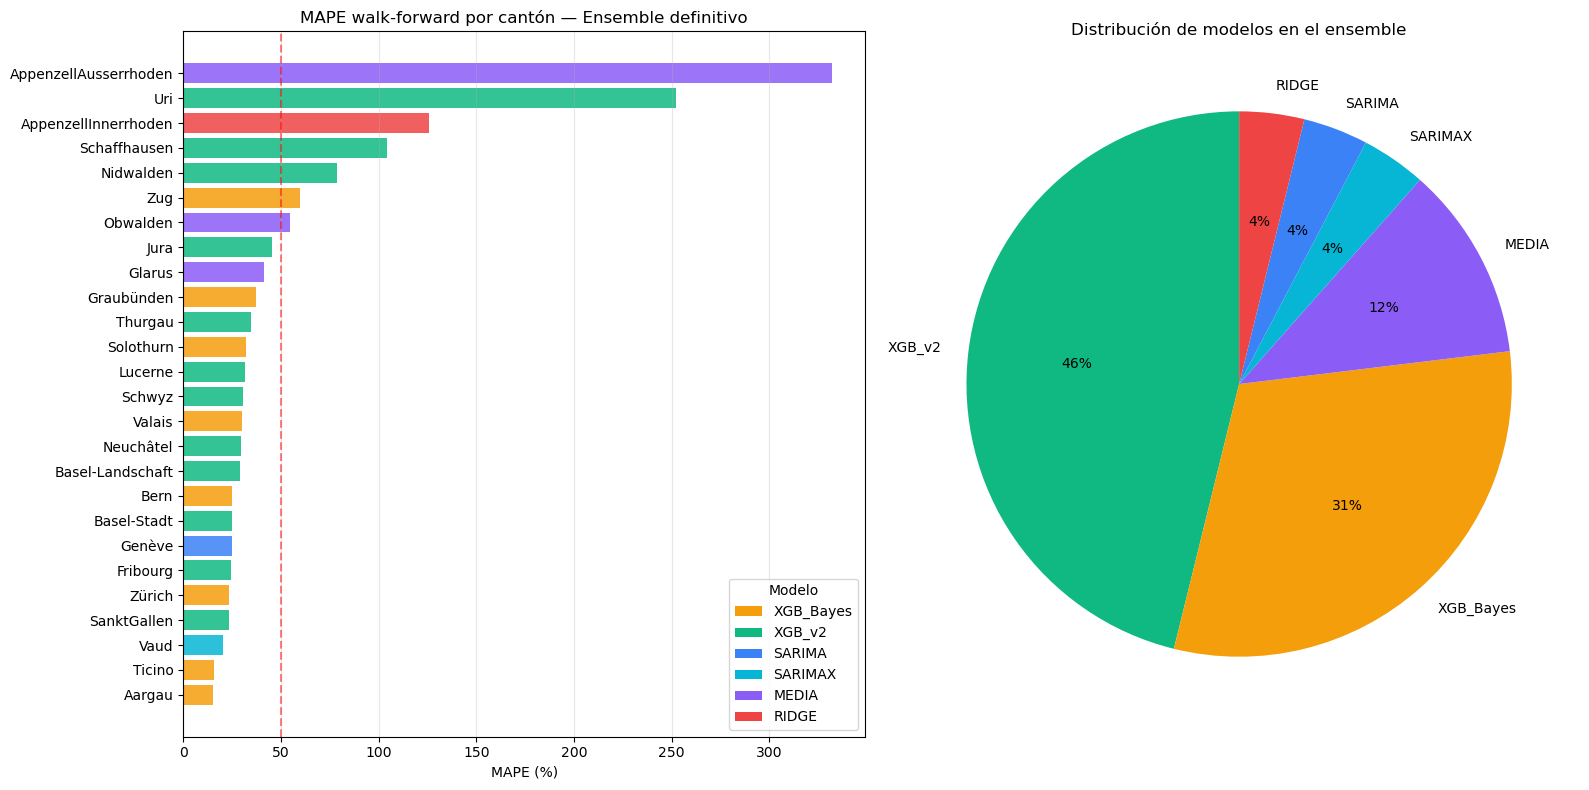

MAPE medio: 59.5
modelo
XGB_v2       12
XGB_Bayes     8
MEDIA         3
SARIMAX       1
SARIMA        1
RIDGE         1
Name: count, dtype: int64


In [82]:
# Gráfica 1 — Ensemble final: MAPE por cantón + distribución de modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colores_modelo = {
    'XGB_Bayes': '#F59E0B',
    'XGB_v2': '#10B981',
    'SARIMA': '#3B82F6',
    'SARIMAX': '#06B6D4',
    'MEDIA': '#8B5CF6',
    'RIDGE': '#EF4444'
}

df_plot = df_ensemble_final.sort_values('mape')
colores = [colores_modelo[m] for m in df_plot['modelo']]

axes[0].barh(df_plot['canton'], df_plot['mape'], color=colores, alpha=0.85)
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Umbral 50%')
axes[0].set_title('MAPE walk-forward por cantón — Ensemble definitivo')
axes[0].set_xlabel('MAPE (%)')
axes[0].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m, c in colores_modelo.items()]
axes[0].legend(handles=legend_elements, title='Modelo')

modelo_count = df_ensemble_final['modelo'].value_counts()
axes[1].pie(modelo_count, labels=modelo_count.index,
            colors=[colores_modelo[m] for m in modelo_count.index],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Distribución de modelos en el ensemble')

plt.tight_layout()
plt.savefig('modelado_ensemble_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('MAPE medio:', df_ensemble_final['mape'].mean().round(1))
print(df_ensemble_final['modelo'].value_counts())

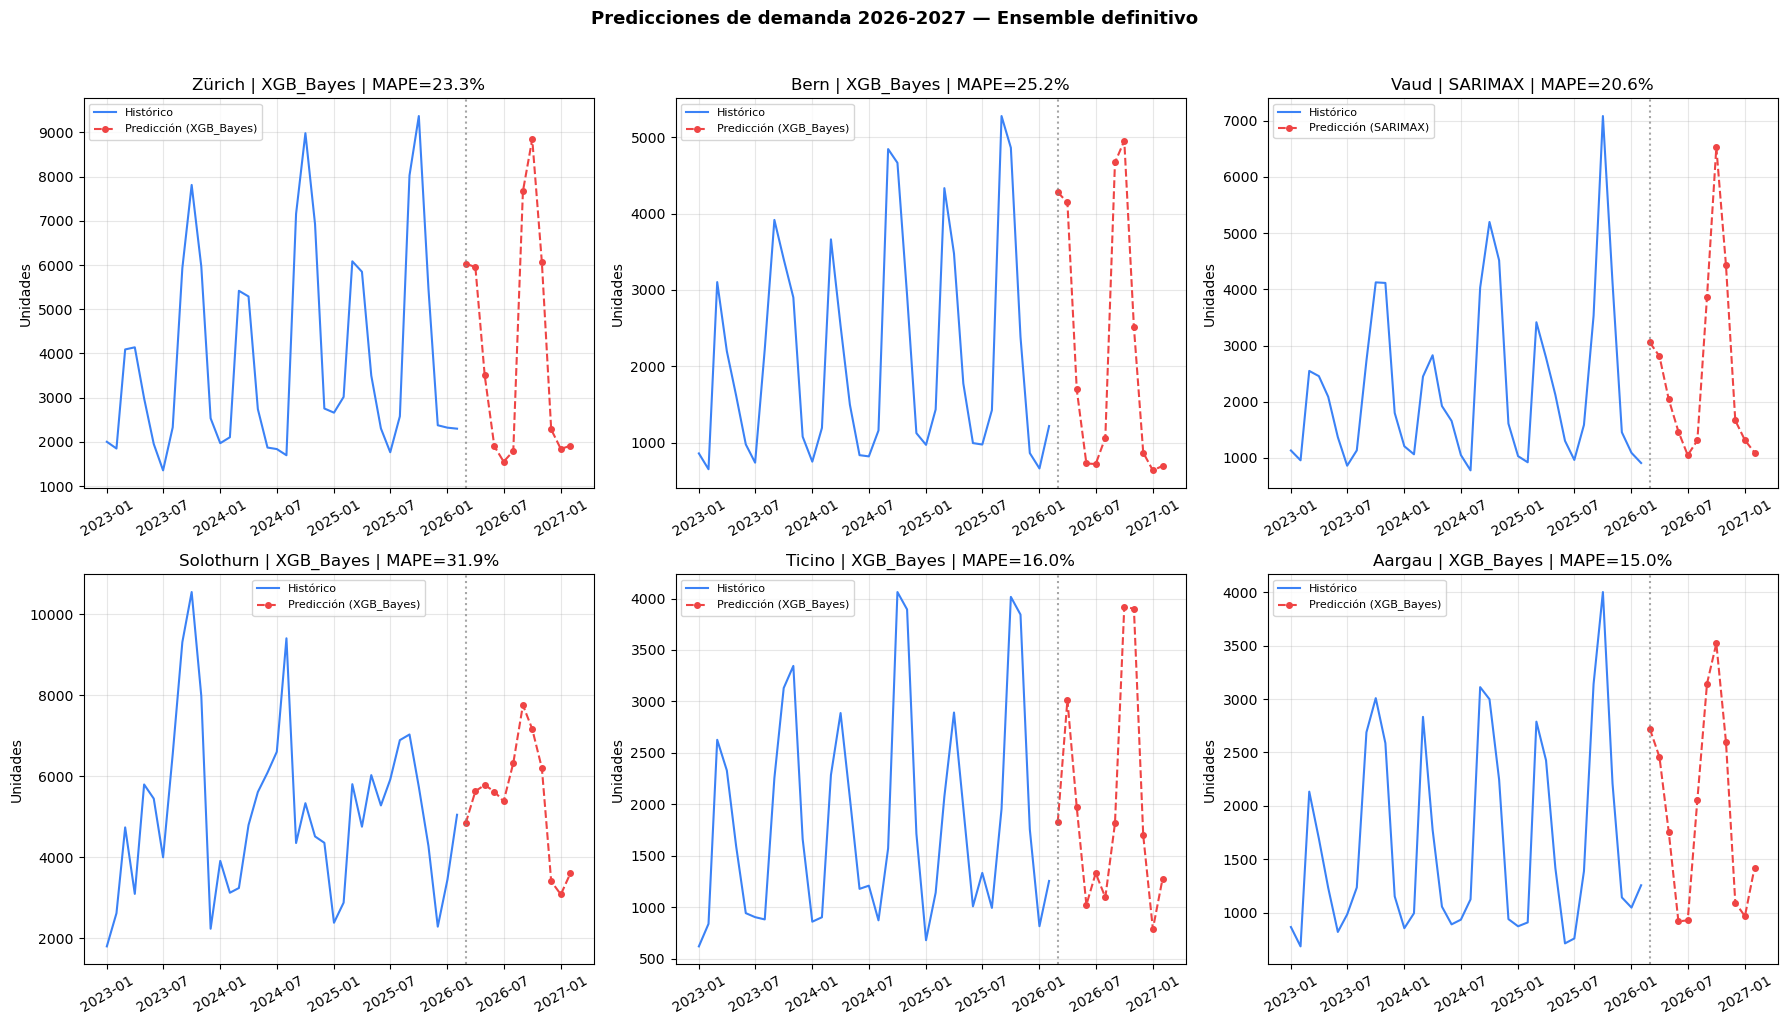

In [83]:
# Gráfica 2 — Predicciones vs histórico top cantones
cantones_top = ['Zürich', 'Bern', 'Vaud', 'Solothurn', 'Ticino', 'Aargau']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, canton in enumerate(cantones_top):
    ax = axes[i]
    
    hist = df_master_v2[df_master_v2['canton'] == canton][['fecha', 'sell_out']].dropna()
    hist_recent = hist[hist['fecha'] >= '2023-01-01']
    pred = df_pred_final[df_pred_final['canton'] == canton]
    modelo = df_ensemble_final[df_ensemble_final['canton'] == canton]['modelo'].values[0]
    mape_val = df_ensemble_final[df_ensemble_final['canton'] == canton]['mape'].values[0]
    
    ax.plot(hist_recent['fecha'], hist_recent['sell_out'],
            color='#3B82F6', linewidth=1.5, label='Histórico')
    ax.plot(pred['fecha'], pred['prediccion'],
            color='#EF4444', linewidth=1.5, linestyle='--',
            marker='o', markersize=4, label=f'Predicción ({modelo})')
    ax.axvline(x=pd.Timestamp('2026-03-01'), color='gray',
               linestyle=':', alpha=0.7)
    
    ax.set_title(f'{canton} | {modelo} | MAPE={mape_val:.1f}%')
    ax.set_ylabel('Unidades')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicciones de demanda 2026-2027 — Ensemble definitivo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('modelado_predicciones_final.png', dpi=150, bbox_inches='tight')
plt.show()

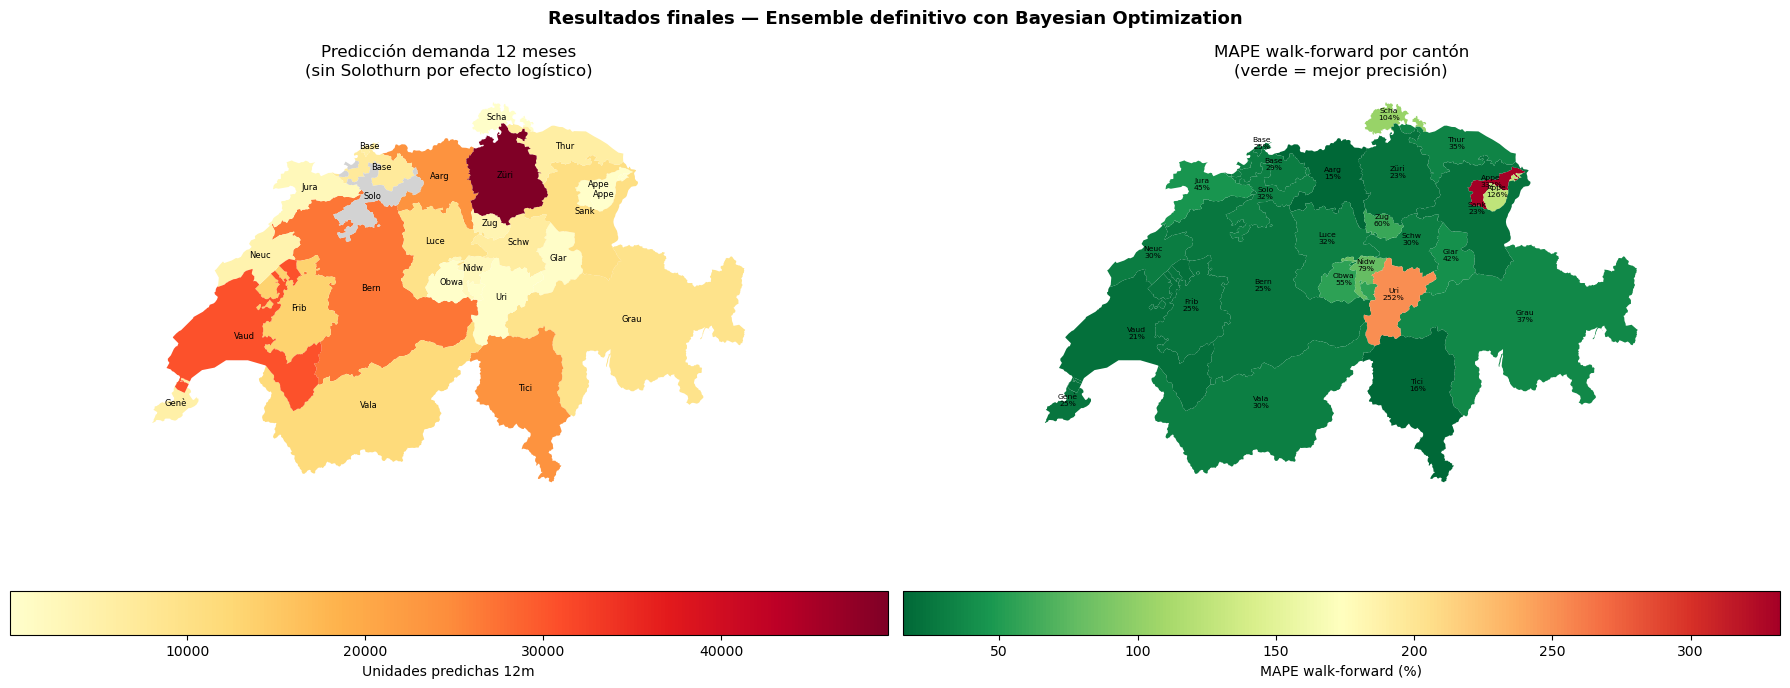

In [84]:
# Gráfica 3 — Mapa coroplético predicciones y MAPE
resumen_mapa = df_pred_final.groupby('canton')['prediccion'].sum().reset_index()
resumen_mapa.columns = ['canton', 'total_12m']
resumen_mapa = resumen_mapa.merge(
    df_ensemble_final[['canton', 'modelo', 'mape']], on='canton', how='left')

cantons_mapa = cantons.merge(resumen_mapa, left_on='NAME_1', right_on='canton', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Mapa predicción sin Solothurn
cantons_plot = cantons_mapa.copy()
cantons_plot.loc[cantons_plot['canton'] == 'Solothurn', 'total_12m'] = None

cantons_plot.plot(column='total_12m', ax=axes[0], cmap='YlOrRd', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos / Outlier'},
    legend_kwds={'label': 'Unidades predichas 12m', 'orientation': 'horizontal'})
for _, row in cantons_plot.iterrows():
    if row['geometry'] is not None:
        axes[0].annotate(row['NAME_1'][:4],
                        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                        fontsize=6, ha='center')
axes[0].set_title('Predicción demanda 12 meses\n(sin Solothurn por efecto logístico)')
axes[0].set_axis_off()

# Mapa MAPE
cantons_mapa.plot(column='mape', ax=axes[1], cmap='RdYlGn_r', legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'MAPE walk-forward (%)', 'orientation': 'horizontal'})
for _, row in cantons_mapa.iterrows():
    if row['geometry'] is not None and pd.notnull(row.get('mape')):
        axes[1].annotate(f"{row['NAME_1'][:4]}\n{row['mape']:.0f}%",
                        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                        fontsize=5.5, ha='center')
axes[1].set_title('MAPE walk-forward por cantón\n(verde = mejor precisión)')
axes[1].set_axis_off()

plt.suptitle('Resultados finales — Ensemble definitivo con Bayesian Optimization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelado_mapa_final.png', dpi=150, bbox_inches='tight')
plt.show()